In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt



import random


from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


import tensorflow as tf

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


from sklearn.preprocessing import StandardScaler

import json
import shutil
from pathlib import Path

from google.colab import files


In [2]:
# df = pd.read_csv("E:\Document\PROJECT\data\processed\data2225_done.csv")
# df = pd.read_csv("data/processed/data2225_done.csv")


df = pd.read_csv('/content/data2225_done.csv')
df.head()

,Local Time,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,IsHoliday,Accumulated Hours of Rain
0,2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95.0,15.5,0.6,2.00,False,0
1,2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94.0,15.4,0.7,2.33,False,0
2,2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93.0,15.3,1.0,2.66,False,1
3,2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93.0,15.2,1.5,3.00,False,2
4,2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87.0,15.6,1.9,3.00,False,0


In [3]:
df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

agg_map = {col: "mean" for col in df.columns}
if "IsHoliday" in agg_map:
    agg_map["IsHoliday"] = "max"

df = df.resample("3H").agg(agg_map).dropna().copy()

/tmp/ipykernel_1952/4140810184.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("3H").agg(agg_map).dropna().copy()


## 3. Khám phá dữ liệu ban đầu

Quan sát đặc trưng theo thời gian và phân phối của các biến nhận diện tính chu kỳ, độ lệch phân phối và mức độ phù hợp của các phép biến đổi tiếp theo.

In [4]:
# ===== Time features =====
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek   # Monday=0, Sunday=6
df["month"] = df.index.month

# ===== PM25 lag features =====
df["PM25_lag_1"] = df["PM25"].shift(1)
df["PM25_lag_8"] = df["PM25"].shift(8)
df["PM25_lag_24"] = df["PM25"].shift(24)

# bỏ các dòng đầu bị NaN do lag/rolling
df = df.dropna().copy()

print(df[[
    "PM25", "PM25_lag_1", "PM25_lag_8", "PM25_lag_24",
    "hour", "dayofweek", "month"
]].head())

                          PM25  PM25_lag_1  PM25_lag_8  PM25_lag_24  hour  \
Local Time                                                                  
2022-01-16 06:00:00  19.800000   24.063333   34.403333    16.915000     6   
2022-01-16 09:00:00  11.303333   19.800000   18.340000    16.226667     9   
2022-01-16 12:00:00   9.020000   11.303333   10.310000    16.280000    12   
2022-01-16 15:00:00  11.686667    9.020000   13.583333    16.583333    15   
2022-01-16 18:00:00  12.926667   11.686667   21.066667    20.406667    18   

                     dayofweek  month  
Local Time                             
2022-01-16 06:00:00          6      1  
2022-01-16 09:00:00          6      1  
2022-01-16 12:00:00          6      1  
2022-01-16 15:00:00          6      1  
2022-01-16 18:00:00          6      1  


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    "skew": df[num_cols].skew(numeric_only=True),
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "min": df[num_cols].min(numeric_only=True),
    "max": df[num_cols].max(numeric_only=True)
}).sort_values("skew", ascending=False)

skew_df["abs_skew"] = skew_df["skew"].abs()

strong_skew = skew_df[skew_df["abs_skew"] >= 1].sort_values("abs_skew", ascending=False)
moderate_skew = skew_df[(skew_df["abs_skew"] >= 0.5) & (skew_df["abs_skew"] < 1)]

print("=== Cột lệch mạnh ===")
print(strong_skew[["skew", "mean", "median", "min", "max"]])

print("\n=== Cột lệch vừa ===")
print(moderate_skew[["skew", "mean", "median", "min", "max"]])

=== Cột lệch mạnh ===
                               skew        mean      median        min  \
Precipitation              5.992642    0.308929    0.000000   0.000000   
Accumulated Hours of Rain  5.780818    1.287799    0.000000   0.000000   
PM10                       4.776306   42.596196   30.933333   0.620000   
IsHoliday                  4.465862    0.043681    0.000000   0.000000   
SO2                        4.053063   36.267982   29.450000   0.166667   
NO2                        3.831239   18.323502   11.540000   0.100000   
CO                         3.315090  523.541938  200.533333  10.000000   
PM25_lag_24                2.543011   21.103650   16.686667   0.480000   
PM25_lag_8                 2.541773   21.107713   16.693333   0.480000   
PM25_lag_1                 2.536982   21.130055   16.713333   0.480000   
PM25                       2.536391   21.131560   16.713333   0.480000   
UV Index                   1.883224    1.308482    0.466667   0.000000   
O3              

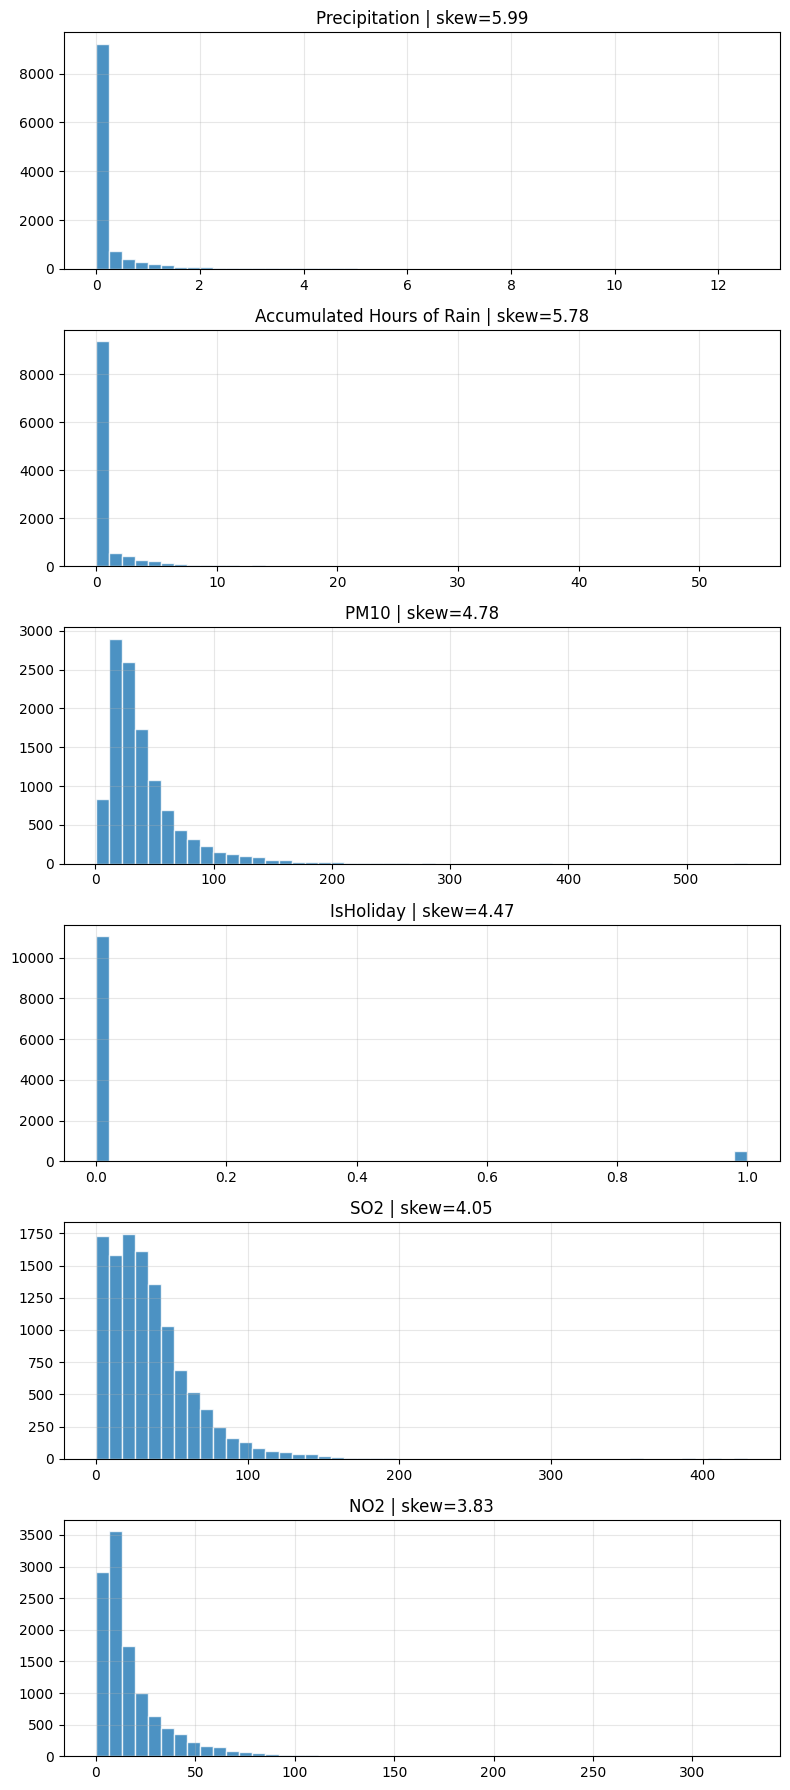

In [6]:
cols_to_plot = strong_skew.index.tolist()[:6]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(8, 3*len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Phân chia tập dữ liệu

In [7]:
# đảm bảo index là datetime
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ===== Split theo tỷ lệ 70/15/15, giữ nguyên thứ tự thời gian =====
n_total = len(df)
train_size = int(n_total * 0.70)
val_size = int(n_total * 0.15)
test_size = n_total - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

train_end = train_df.index.max()
val_start = val_df.index.min()
val_end = val_df.index.max()
test_start = test_df.index.min()

print("Kích thước train/val/test:", train_df.shape, val_df.shape, test_df.shape)
print("Moc thoi gian:")
print("train:", train_df.index.min(), "->", train_end)
print("val  :", val_start, "->", val_end)
print("test :", test_start, "->", test_df.index.max())

Kích thước train/val/test: (8092, 21) (1734, 21) (1735, 21)
Moc thoi gian:
train: 2022-01-16 06:00:00 -> 2024-10-23 15:00:00
val  : 2024-10-23 18:00:00 -> 2025-05-28 18:00:00
test : 2025-05-28 21:00:00 -> 2025-12-31 21:00:00


## 5. Biến đổi biến mục tiêu

Do phân phối của PM2.5 thường lệch phải và chứa các giá trị đỉnh, phép biến đổi `log1p` được áp dụng nhằm giảm ảnh hưởng của ngoại lệ và cải thiện độ ổn định khi huấn luyện. Sau dự báo, các giá trị được biến đổi ngược về thang đo ban đầu để đánh giá.

In [8]:
y_train_raw = train_df["PM25"].to_numpy()
y_val_raw = val_df["PM25"].to_numpy()
y_test_raw = test_df["PM25"].to_numpy()

train_log = np.log1p(train_df["PM25"])
val_log = np.log1p(val_df["PM25"])
test_log = np.log1p(test_df["PM25"])

y_train_t = train_log.to_numpy()
y_val_t = val_log.to_numpy()
y_test_t = test_log.to_numpy()

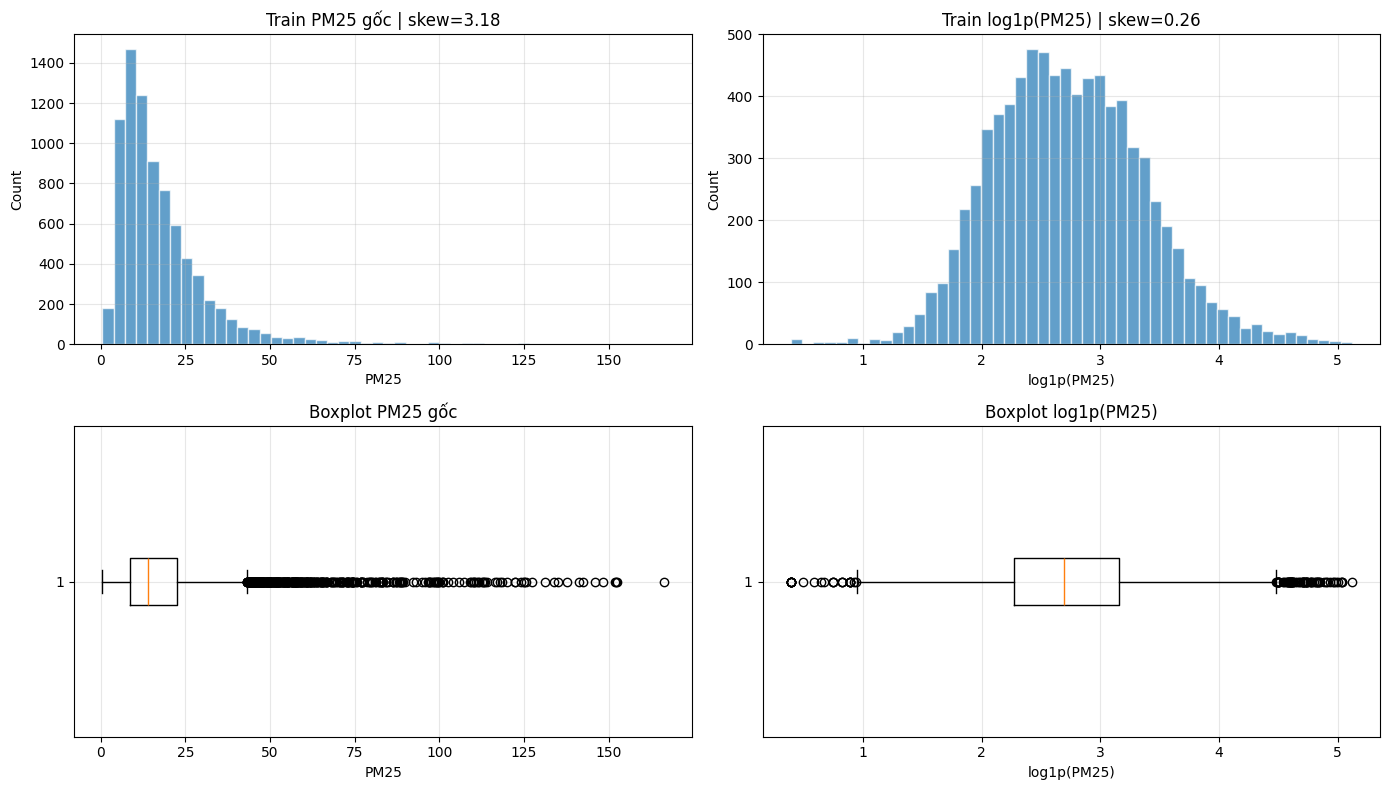

Độ lệch (skew) của dữ liệu gốc: 3.1833155215045283
Độ lệch (skew) sau log: 0.2648290972292766


In [9]:

y_train_raw_1d = y_train_raw.ravel()
y_val_raw_1d   = y_val_raw.ravel()
y_test_raw_1d  = y_test_raw.ravel()

y_train_t_1d = y_train_t.ravel()
y_val_t_1d   = y_val_t.ravel()
y_test_t_1d  = y_test_t.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Histogram trước log
axes[0, 0].hist(y_train_raw_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 0].set_title(f"Train PM25 gốc | skew={pd.Series(y_train_raw_1d).skew():.2f}")
axes[0, 0].set_xlabel("PM25")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# 2) Histogram sau log1p
axes[0, 1].hist(y_train_t_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 1].set_title(f"Train log1p(PM25) | skew={pd.Series(y_train_t_1d).skew():.2f}")
axes[0, 1].set_xlabel("log1p(PM25)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# 3) Boxplot trước log
axes[1, 0].boxplot(y_train_raw_1d, vert=False)
axes[1, 0].set_title("Boxplot PM25 gốc")
axes[1, 0].set_xlabel("PM25")
axes[1, 0].grid(alpha=0.3)

# 4) Boxplot sau log1p
axes[1, 1].boxplot(y_train_t_1d, vert=False)
axes[1, 1].set_title("Boxplot log1p(PM25)")
axes[1, 1].set_xlabel("log1p(PM25)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Độ lệch (skew) của dữ liệu gốc:", pd.Series(y_train_raw_1d).skew())
print("Độ lệch (skew) sau log:", pd.Series(y_train_t_1d).skew())

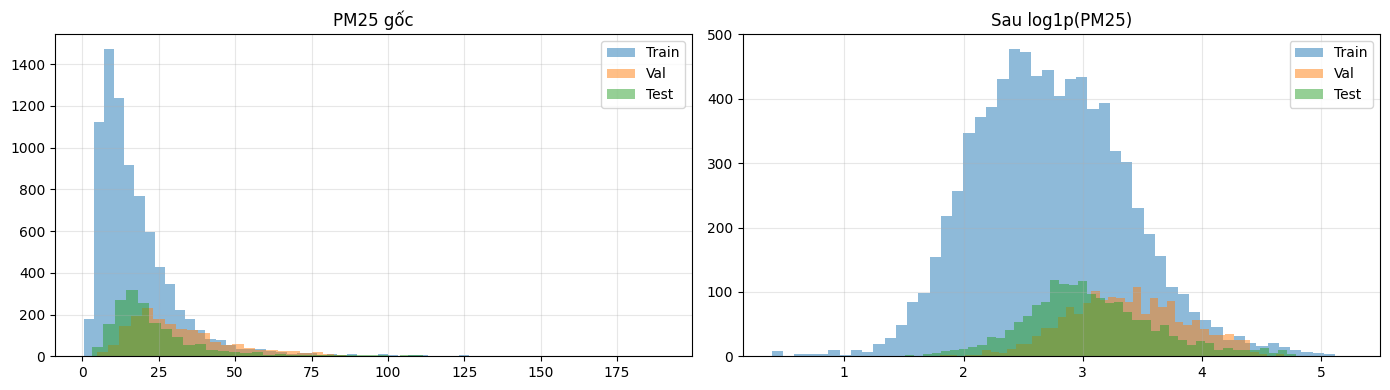

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.5, label="Train")
axes[0].hist(y_val_raw.ravel(), bins=50, alpha=0.5, label="Val")
axes[0].hist(y_test_raw.ravel(), bins=50, alpha=0.5, label="Test")
axes[0].set_title("PM25 gốc")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.5, label="Train")
axes[1].hist(y_val_t.ravel(), bins=50, alpha=0.5, label="Val")
axes[1].hist(y_test_t.ravel(), bins=50, alpha=0.5, label="Test")
axes[1].set_title("Sau log1p(PM25)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

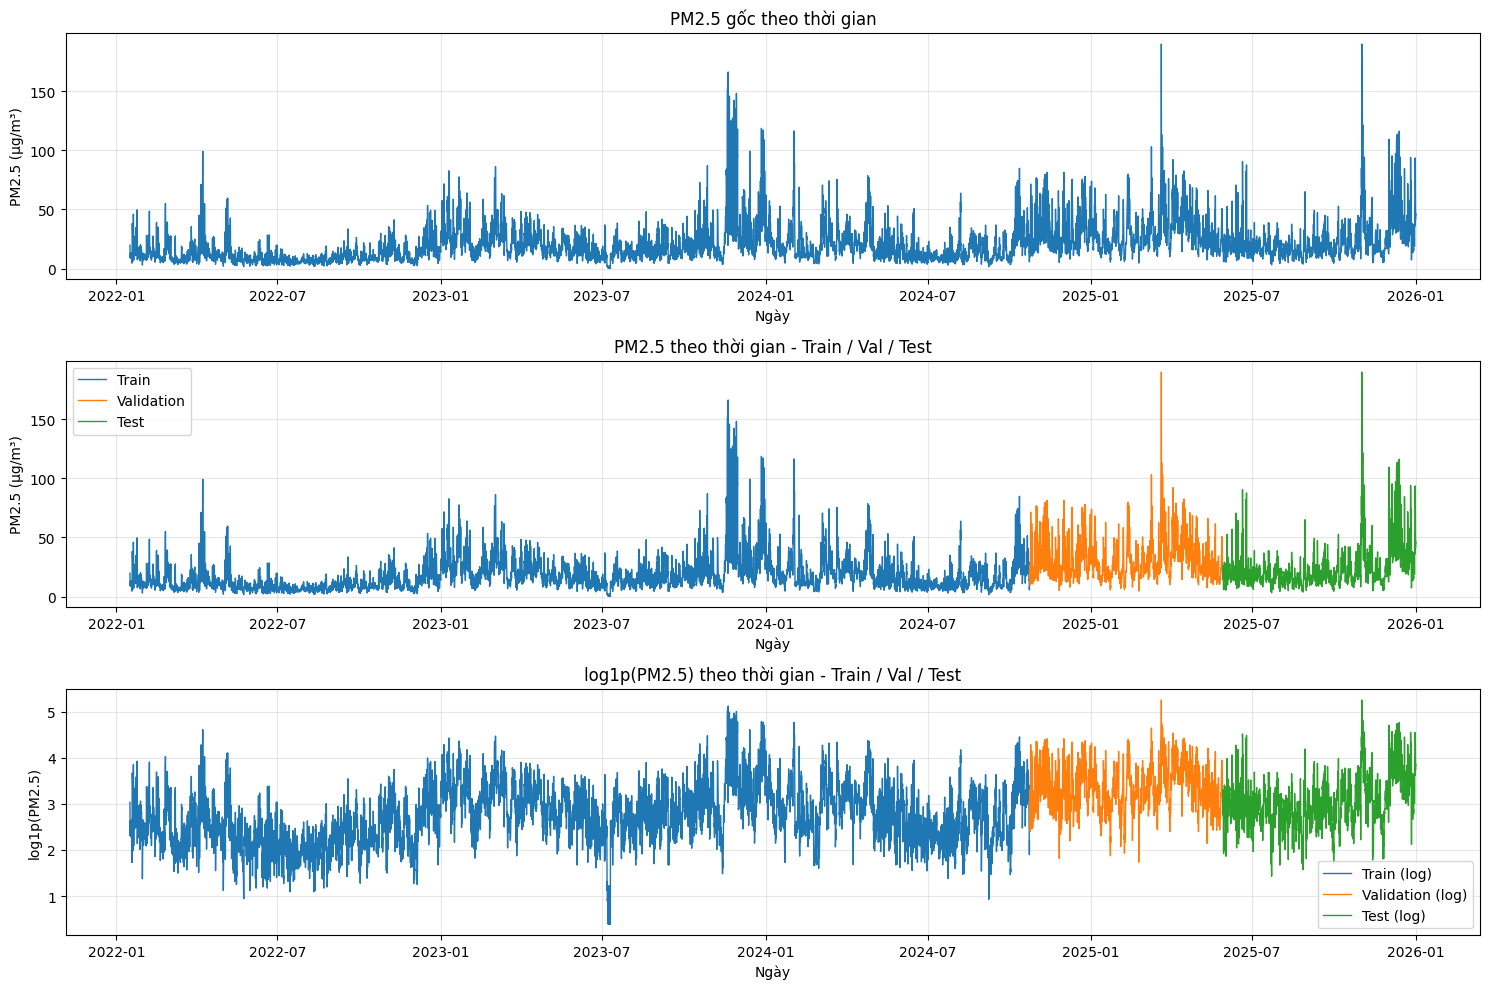

In [11]:


# ===== Tạo log PM25 =====
train_log = np.log1p(train_df["PM25"])
val_log   = np.log1p(val_df["PM25"])
test_log  = np.log1p(test_df["PM25"])

# ===== Vẽ =====
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1) PM2.5 gốc toàn bộ theo thời gian
axes[0].plot(df.index, df["PM25"], linewidth=1)
axes[0].set_title("PM2.5 gốc theo thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xlabel("Ngày")
axes[0].grid(True, alpha=0.3)

# 2) PM2.5 gốc theo split Train / Val / Test
axes[1].plot(train_df.index, train_df["PM25"], label="Train", linewidth=1)
axes[1].plot(val_df.index, val_df["PM25"], label="Validation", linewidth=1)
axes[1].plot(test_df.index, test_df["PM25"], label="Test", linewidth=1)
axes[1].set_title("PM2.5 theo thời gian - Train / Val / Test")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Ngày")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) log1p(PM2.5) theo split Train / Val / Test
axes[2].plot(train_df.index, train_log, label="Train (log)", linewidth=1)
axes[2].plot(val_df.index, val_log, label="Validation (log)", linewidth=1)
axes[2].plot(test_df.index, test_log, label="Test (log)", linewidth=1)
axes[2].set_title("log1p(PM2.5) theo thời gian - Train / Val / Test")
axes[2].set_ylabel("log1p(PM2.5)")
axes[2].set_xlabel("Ngày")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Tạo đặc trưng đầu vào

Các đặc trưng đầu vào được xây dựng từ thông tin lịch, các biến trễ của PM2.5 và các thống kê theo cùng khung giờ ở những ngày trước đó. Cách thiết kế này giúp mô hình khai thác đồng thời tính chu kỳ và động học ngắn hạn của chuỗi.

In [12]:


df = df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

for lag in [1, 8, 16, 24, 32, 40, 48, 56]:
    df[f"PM25_lag_{lag}"] = df["PM25"].shift(lag)

shifted = df["PM25"].shift(1)
df["PM25_roll_mean_8"] = shifted.rolling(window=8).mean()
df["PM25_roll_std_8"] = shifted.rolling(window=8).std()
df["PM25_roll_max_8"] = shifted.rolling(window=8).max()
df["PM25_roll_min_8"] = shifted.rolling(window=8).min()
df["PM25_roll_mean_24"] = shifted.rolling(window=24).mean()
df["PM25_roll_std_24"] = shifted.rolling(window=24).std()
df["PM25_roll_max_24"] = shifted.rolling(window=24).max()
df["PM25_roll_min_24"] = shifted.rolling(window=24).min()

df["PM25_diff_1"] = shifted.diff(1)
df["PM25_diff_8"] = shifted.diff(8)
same_hour_lags_3d = ["PM25_lag_8", "PM25_lag_16", "PM25_lag_24"]
same_hour_lags_7d = [
    "PM25_lag_8", "PM25_lag_16", "PM25_lag_24", "PM25_lag_32",
    "PM25_lag_40", "PM25_lag_48", "PM25_lag_56",
]
df["PM25_same_hour_mean_3d"] = df[same_hour_lags_3d].mean(axis=1)
df["PM25_same_hour_mean_7d"] = df[same_hour_lags_7d].mean(axis=1)
df["PM25_same_hour_std_7d"] = df[same_hour_lags_7d].std(axis=1)
df["PM25_same_hour_max_7d"] = df[same_hour_lags_7d].max(axis=1)

df = df.dropna().copy()

base_features = [
    "PM25_lag_1", "PM25_lag_8", "PM25_lag_24", "PM25_lag_56",
    "PM25_roll_mean_8", "PM25_roll_std_8", "PM25_roll_max_8", "PM25_roll_min_8",
    "PM25_roll_mean_24", "PM25_roll_std_24", "PM25_roll_max_24", "PM25_roll_min_24",
    "PM25_diff_1", "PM25_diff_8",
    "PM25_same_hour_mean_3d", "PM25_same_hour_mean_7d", "PM25_same_hour_std_7d", "PM25_same_hour_max_7d",
]

weather_features = [
    "Temperature", "Pressure", "Wind Speed",
    "Clouds", "Precipitation", "Relative Humidity",
    "Accumulated Hours of Rain",
]

pollution_features = ["PM10", "CO", "NO2", "O3", "SO2"]

calendar_features = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "IsHoliday",
]

manual_v1_features = (
    base_features
    + ["PM10", "CO", "NO2"]
    + ["Temperature", "Pressure", "Wind Speed", "Relative Humidity", "Precipitation", "Clouds"]
    + calendar_features
)

production_v1_features = base_features + calendar_features

feature_groups = {
    "base": base_features,
    "weather": weather_features,
    "pollution": pollution_features,
    "calendar": calendar_features,
}

candidate_feature_sets = {
    "base": base_features,
    "base_weather": base_features + weather_features,
    "base_weather_pollution": base_features + weather_features + pollution_features,
    "manual_v1": manual_v1_features,
    "production_v1": production_v1_features,
    "optimistic_v1": manual_v1_features,
    "all": base_features + weather_features + pollution_features + calendar_features,
}

GRA_POOL_NAME = "all"
GRA_TOP_K = 15
GRA_RHO = 0.5


def _minmax_01(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype=np.float64)
    return (values - vmin) / (vmax - vmin)


def compute_gra_scores(X_df, y_series, rho=0.5):
    ref = _minmax_01(np.asarray(y_series, dtype=np.float64).reshape(-1))
    diffs = []
    normalized = {}

    for col in X_df.columns:
        seq = _minmax_01(X_df[col].to_numpy(dtype=np.float64))
        normalized[col] = seq
        diffs.append(np.abs(ref - seq))

    diff_matrix = np.vstack(diffs)
    delta_min = float(np.min(diff_matrix))
    delta_max = float(np.max(diff_matrix))
    if np.isclose(delta_max, 0.0):
        delta_max = 1.0

    rows = []
    for col in X_df.columns:
        diff = np.abs(ref - normalized[col])
        coeff = (delta_min + rho * delta_max) / (diff + rho * delta_max)
        rows.append({
            "feature": col,
            "gra_score": float(np.mean(coeff)),
        })

    return pd.DataFrame(rows).sort_values(["gra_score", "feature"], ascending=[False, True]).reset_index(drop=True)


for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: thiếu cột -> {missing_cols}")
    else:
        print(f"{name}: {len(cols)} đặc trưng")

feature_cols = candidate_feature_sets["manual_v1"]
print('Bộ đặc trưng đang dùng:', feature_cols)


base: 18 đặc trưng
base_weather: 25 đặc trưng
base_weather_pollution: 30 đặc trưng
manual_v1: 34 đặc trưng
production_v1: 25 đặc trưng
optimistic_v1: 34 đặc trưng
all: 37 đặc trưng
Bộ đặc trưng đang dùng: ['PM25_lag_1', 'PM25_lag_8', 'PM25_lag_24', 'PM25_lag_56', 'PM25_roll_mean_8', 'PM25_roll_std_8', 'PM25_roll_max_8', 'PM25_roll_min_8', 'PM25_roll_mean_24', 'PM25_roll_std_24', 'PM25_roll_max_24', 'PM25_roll_min_24', 'PM25_diff_1', 'PM25_diff_8', 'PM25_same_hour_mean_3d', 'PM25_same_hour_mean_7d', 'PM25_same_hour_std_7d', 'PM25_same_hour_max_7d', 'PM10', 'CO', 'NO2', 'Temperature', 'Pressure', 'Wind Speed', 'Relative Humidity', 'Precipitation', 'Clouds', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']


## 7. Cấu hình

In [13]:
# CẤU HÌNH CHUNG CHO MÔ HÌNH

LOOKBACK = 112
CHUNK_HORIZON = 1
ROLLOUT_HORIZON = 24
N_CHUNKS = ROLLOUT_HORIZON // CHUNK_HORIZON
HORIZON = CHUNK_HORIZON
EVAL_SIZE = ROLLOUT_HORIZON
STEP_SIZE = ROLLOUT_HORIZON
STEP_HOURS = 3
MAX_FOLDS = 4
EPOCHS = 70
BATCH_SIZE = 64
SEED = 62
TARGET_TRANSFORM_MODE = "log1p"
SELECTED_FEATURE_SET = "all"
OPTIMISTIC_FEATURE_SET = "optimistic_v1"
INNER_VAL_SIZE = 56
PEAK_QUANTILE = 0.90
PEAK_WEIGHT = 2.5
HUBER_DELTA = 1.0
FINAL_EPOCH_FLOOR = 10
EARLY_STOPPING_PATIENCE = 24
LR_REDUCE_PATIENCE = 8
ROLLING_POLICY = "assimilated"
FEATURE_SET_COMPARE = [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Không bật được deterministic ops:", exc)

production_feature_cols = candidate_feature_sets[SELECTED_FEATURE_SET]
optimistic_feature_cols = candidate_feature_sets[OPTIMISTIC_FEATURE_SET]
feature_cols = production_feature_cols

print("Bộ đặc trưng production đang dùng:", SELECTED_FEATURE_SET)
print("Số lượng đặc trưng production:", len(production_feature_cols))
print("LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON:", LOOKBACK, CHUNK_HORIZON, ROLLOUT_HORIZON)
print("MAX_FOLDS, EPOCHS:", MAX_FOLDS, EPOCHS)
print("INNER_VAL_SIZE:", INNER_VAL_SIZE)
print("TARGET_TRANSFORM_MODE:", TARGET_TRANSFORM_MODE)
print("FINAL_EPOCH_FLOOR / EARLY_STOPPING_PATIENCE:", FINAL_EPOCH_FLOOR, EARLY_STOPPING_PATIENCE)


Bộ đặc trưng production đang dùng: all
Số lượng đặc trưng production: 37
LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON: 112 1 24
MAX_FOLDS, EPOCHS: 4 70
INNER_VAL_SIZE: 56
TARGET_TRANSFORM_MODE: log1p
FINAL_EPOCH_FLOOR / EARLY_STOPPING_PATIENCE: 10 24


# 8. Chuẩn bị dữ liệu cho huấn luyện

Dữ liệu được chuẩn hóa, biến đổi biến mục tiêu và đóng gói thành các chuỗi đầu vào phù hợp với kiến trúc mô hình. Việc duy trì quy trình tiền xử lý nhất quán giữa tập huấn luyện, kiểm định và kiểm tra là cần thiết để bảo đảm tính công bằng và độ tin cậy của quá trình đánh giá.

In [14]:
# ===== Xây dựng mô hình Seq2Seq GRU + Attention =====
def make_sequences(X, y, lookback, horizon):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]
        decoder_seed = np.concatenate([[y[i + lookback - 1]], y_future[:-1]]).astype(np.float32)
        decoder_seq.append(decoder_seed.reshape(-1, 1))
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )

## 9. Đánh giá
Hiệu năng mô hình được đánh giá bằng các chỉ số MAE, RMSE và MAPE để phản ánh sai số dự báo trên toàn bộ tập dữ liệu. Ngoài ra, chỉ số peak_mae được sử dụng để theo dõi sai số tại các điểm đỉnh, qua đó đánh giá khả năng dự báo của mô hình trong những giai đoạn ô nhiễm tăng mạnh.

In [15]:
# tính toán các metric MAE, RMSE, MAPE tổng thể và riêng cho các điểm đỉnh (peak) dựa trên ngưỡng quantile.
def compute_regression_metrics(y_true_flat, y_pred_flat, peak_quantile=0.90):
    y_true_flat = np.asarray(y_true_flat, dtype=np.float64).reshape(-1)
    y_pred_flat = np.asarray(y_pred_flat, dtype=np.float64).reshape(-1)

    metrics = {
        "mae": mean_absolute_error(y_true_flat, y_pred_flat),
        "rmse": np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        "mape": np.mean(
            np.abs((y_true_flat - y_pred_flat) / np.clip(np.abs(y_true_flat), 1e-6, None))
        ) * 100,
    }

    peak_threshold = float(np.quantile(y_true_flat, peak_quantile))
    peak_mask = y_true_flat >= peak_threshold
    metrics["peak_threshold"] = peak_threshold
    metrics["peak_mae"] = mean_absolute_error(y_true_flat[peak_mask], y_pred_flat[peak_mask]) if np.any(peak_mask) else np.nan
    return metrics


def aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d):
    rows = []
    y_true_2d = np.asarray(y_true_2d, dtype=np.float64)
    y_pred_2d = np.asarray(y_pred_2d, dtype=np.float64)

    for seq_idx in range(y_pred_2d.shape[0]):
        for h in range(y_pred_2d.shape[1]):
            rows.append({
                "timestamp": eval_index[seq_idx + h],
                "horizon_step": h + 1,
                "y_true": y_true_2d[seq_idx, h],
                "y_pred": y_pred_2d[seq_idx, h],
            })

    long_df = pd.DataFrame(rows)
    agg_df = (
        long_df.groupby("timestamp", as_index=False)
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            pred_std=("y_pred", "std"),
            n_votes=("y_pred", "size"),
        )
        .sort_values("timestamp")
    )
    agg_df["pred_std"] = agg_df["pred_std"].fillna(0.0)
    return long_df, agg_df


# Tính metric riêng cho từng horizon step.
def compute_horizon_step_metrics(long_df, peak_quantile=0.90):
    rows = []
    for horizon_step, step_df in long_df.groupby("horizon_step", sort=True):
        metrics = compute_regression_metrics(
            step_df["y_true"].to_numpy(),
            step_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        rows.append({
            "horizon_step": int(horizon_step),
            "n_points": int(len(step_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })
    return pd.DataFrame(rows)


# Gom toàn bộ quy trình đánh giá multi-step forecasting: từ long format, aggregate theo timestamp, tính metric theo horizon step, và metric tổng thể.
def summarize_multistep_predictions(eval_index, y_true_2d, y_pred_2d, peak_quantile=0.90):
    long_df, agg_df = aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d)
    horizon_metrics_df = compute_horizon_step_metrics(long_df, peak_quantile=peak_quantile)
    step1_df = long_df[long_df["horizon_step"] == 1].sort_values("timestamp").reset_index(drop=True)

    raw_metrics = compute_regression_metrics(
        np.asarray(y_true_2d, dtype=np.float64).reshape(-1),
        np.asarray(y_pred_2d, dtype=np.float64).reshape(-1),
        peak_quantile=peak_quantile,
    )
    step1_metrics = compute_regression_metrics(
        step1_df["y_true"].to_numpy(),
        step1_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    agg_metrics = compute_regression_metrics(
        agg_df["y_true"].to_numpy(),
        agg_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )

    return {
        "long_df": long_df,
        "agg_df": agg_df,
        "step1_df": step1_df,
        "horizon_metrics_df": horizon_metrics_df,
        "raw_metrics": raw_metrics,
        "step1_metrics": step1_metrics,
        "agg_metrics": agg_metrics,
    }



# ===== Biểu đồ zoom riêng cho từng mô hình trên tập test =====
def plot_model_zoom(timeline_df, model_label, color, days=14, step_hours=STEP_HOURS):
    plot_df = timeline_df[["timestamp", "y_true", "y_pred"]].copy()
    plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"])
    zoom_n = min(len(plot_df), int(days * 24 / step_hours))
    zoom_df = plot_df.tail(zoom_n).copy()

    plt.figure(figsize=(15, 5))
    plt.plot(
        zoom_df["timestamp"],
        zoom_df["y_true"],
        label="Thực tế (Test)",
        linewidth=1.9,
        color="#4C72B0",
    )
    plt.plot(
        zoom_df["timestamp"],
        zoom_df["y_pred"],
        label=model_label,
        linewidth=1.8,
        color=color,
    )
    plt.title(f"Biểu đồ zoom {zoom_n} mốc cuối của backtest {model_label}")
    plt.xlabel("Thời gian")
    plt.ylabel("PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()



In [16]:

def transform_target(y_raw, scaler=None, fit=False, mode="log1p"):
    y_raw = np.asarray(y_raw, dtype=np.float64).reshape(-1)

    y_clip = np.clip(y_raw, 0.0, None)

    if mode == "log1p":
        y_t = np.log1p(y_clip).reshape(-1, 1)
    elif mode == "sqrt":
        y_t = np.sqrt(y_clip).reshape(-1, 1)
    elif mode == "raw":
        y_t = y_clip.reshape(-1, 1)
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    if fit:
        scaler = StandardScaler()
        scaler.fit(y_t)
    elif scaler is None:
        raise ValueError("Khi fit=False, scaler không được để trống")

    y_scaled = scaler.transform(y_t).reshape(-1)
    return y_scaled, scaler


def inverse_target(y_scaled, scaler, mode="log1p"):
    y_scaled = np.asarray(y_scaled, dtype=np.float64)
    original_shape = y_scaled.shape
    y_unscaled = scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

    if mode == "log1p":
        y_raw = np.expm1(y_unscaled)
    elif mode == "sqrt":
        y_raw = np.square(np.clip(y_unscaled, 0.0, None))
    elif mode == "raw":
        y_raw = y_unscaled
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    y_raw = np.clip(y_raw, 0.0, None)
    return y_raw.reshape(original_shape)

In [17]:
PRODUCTION_LAGS = [1, 8, 16, 24, 32, 40, 48, 56]



def build_history_feature_frame(raw_df):
    raw_df = raw_df.copy().sort_index()

    raw_df["hour"] = raw_df.index.hour
    raw_df["dayofweek"] = raw_df.index.dayofweek
    raw_df["month"] = raw_df.index.month
    raw_df["hour_sin"] = np.sin(2 * np.pi * raw_df["hour"] / 24)
    raw_df["hour_cos"] = np.cos(2 * np.pi * raw_df["hour"] / 24)
    raw_df["dow_sin"] = np.sin(2 * np.pi * raw_df["dayofweek"] / 7)
    raw_df["dow_cos"] = np.cos(2 * np.pi * raw_df["dayofweek"] / 7)
    raw_df["month_sin"] = np.sin(2 * np.pi * raw_df["month"] / 12)
    raw_df["month_cos"] = np.cos(2 * np.pi * raw_df["month"] / 12)

    for lag in PRODUCTION_LAGS:
        raw_df[f"PM25_lag_{lag}"] = raw_df["PM25"].shift(lag)

    shifted = raw_df["PM25"].shift(1)
    raw_df["PM25_roll_mean_8"] = shifted.rolling(window=8).mean()
    raw_df["PM25_roll_std_8"] = shifted.rolling(window=8).std()
    raw_df["PM25_roll_max_8"] = shifted.rolling(window=8).max()
    raw_df["PM25_roll_min_8"] = shifted.rolling(window=8).min()
    raw_df["PM25_roll_mean_24"] = shifted.rolling(window=24).mean()
    raw_df["PM25_roll_std_24"] = shifted.rolling(window=24).std()
    raw_df["PM25_roll_max_24"] = shifted.rolling(window=24).max()
    raw_df["PM25_roll_min_24"] = shifted.rolling(window=24).min()

    raw_df["PM25_diff_1"] = shifted.diff(1)
    raw_df["PM25_diff_8"] = shifted.diff(8)
    same_hour_lags_3d = ["PM25_lag_8", "PM25_lag_16", "PM25_lag_24"]
    same_hour_lags_7d = [
        "PM25_lag_8", "PM25_lag_16", "PM25_lag_24", "PM25_lag_32",
        "PM25_lag_40", "PM25_lag_48", "PM25_lag_56",
    ]
    raw_df["PM25_same_hour_mean_3d"] = raw_df[same_hour_lags_3d].mean(axis=1)
    raw_df["PM25_same_hour_mean_7d"] = raw_df[same_hour_lags_7d].mean(axis=1)
    raw_df["PM25_same_hour_std_7d"] = raw_df[same_hour_lags_7d].std(axis=1)
    raw_df["PM25_same_hour_max_7d"] = raw_df[same_hour_lags_7d].max(axis=1)
    return raw_df



def prepare_train_eval_sequences(train_X_df, train_y_df, eval_X_df, eval_y_df, lookback=72, horizon=72, target_mode="log1p"):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df phải có ít nhất `lookback` hàng")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences(
        X_train_scaled, y_train_scaled, lookback=lookback, horizon=horizon
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])
    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences(
        X_context, y_context, lookback=lookback, horizon=horizon
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def build_inference_inputs(history_raw_df, feature_cols, x_scaler, y_scaler, lookback=72, target_mode="log1p"):
    feature_frame = build_history_feature_frame(history_raw_df)
    feature_frame = feature_frame.dropna(subset=feature_cols + ["PM25"]).copy()
    if len(feature_frame) < lookback:
        raise ValueError("Không đủ lịch sử sau khi tạo feature cho input inference.")

    X_window = feature_frame[feature_cols].tail(lookback).to_numpy(dtype=np.float32)
    X_scaled = x_scaler.transform(X_window)
    last_target_scaled, _ = transform_target(
        np.array([feature_frame["PM25"].iloc[-1]], dtype=np.float32),
        scaler=y_scaler,
        fit=False,
        mode=target_mode,
    )
    return X_scaled[np.newaxis, ...], float(last_target_scaled[0])


def summarize_rollout_predictions(rollout_df, peak_quantile=0.90):
    rollout_df = rollout_df.copy().sort_values("timestamp").reset_index(drop=True)
    rollout_df["pred_std"] = 0.0

    chunk_rows = []
    for chunk_id, chunk_df in rollout_df.groupby("chunk_id", sort=True):
        metrics = compute_regression_metrics(
            chunk_df["y_true"].to_numpy(),
            chunk_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        chunk_rows.append({
            "chunk_id": int(chunk_id),
            "n_points": int(len(chunk_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })

    chunk_metrics_df = pd.DataFrame(chunk_rows)
    rollout_metrics = compute_regression_metrics(
        rollout_df["y_true"].to_numpy(),
        rollout_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    return {
        "timeline_df": rollout_df,
        "chunk_metrics_df": chunk_metrics_df,
        "rollout_metrics": rollout_metrics,
    }

def run_assimilated_rollout(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    decoder_rollout="autoregressive",
):
    if decoder_rollout not in ("autoregressive", "constant_last"):
        raise ValueError('decoder_rollout phải là "autoregressive" hoặc "constant_last".')
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )

        if decoder_rollout == "constant_last":
            decoder_input = np.full((1, chunk_horizon, 1), last_target_scaled, dtype=np.float32)
            y_pred_scaled = model.predict([X_input, decoder_input], verbose=0)[0][:effective_chunk_horizon].astype(
                np.float32
            )
        else:
            decoder_input = np.zeros((1, chunk_horizon, 1), dtype=np.float32)
            decoder_input[0, 0, 0] = last_target_scaled
            y_pred_scaled = np.zeros((chunk_horizon,), dtype=np.float32)
            for step_idx in range(effective_chunk_horizon):
                decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
                y_pred_scaled[step_idx] = decoder_forecast[step_idx]
                if step_idx + 1 < chunk_horizon:
                    decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(
            y_pred_scaled[:effective_chunk_horizon],
            y_scaler,
            mode=target_mode,
        )

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        history_raw_df = pd.concat([history_raw_df, chunk_future], axis=0)

    rollout_df = pd.DataFrame(rows)
    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def run_recursive_rollout(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    decoder_rollout="autoregressive",
):
    if decoder_rollout not in ("autoregressive", "constant_last"):
        raise ValueError('decoder_rollout phải là "autoregressive" hoặc "constant_last".')
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )

        if decoder_rollout == "constant_last":
            decoder_input = np.full((1, chunk_horizon, 1), last_target_scaled, dtype=np.float32)
            y_pred_scaled = model.predict([X_input, decoder_input], verbose=0)[0][:effective_chunk_horizon].astype(
                np.float32
            )
        else:
            decoder_input = np.zeros((1, chunk_horizon, 1), dtype=np.float32)
            decoder_input[0, 0, 0] = last_target_scaled
            y_pred_scaled = np.zeros((chunk_horizon,), dtype=np.float32)
            for step_idx in range(effective_chunk_horizon):
                decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
                y_pred_scaled[step_idx] = decoder_forecast[step_idx]
                if step_idx + 1 < chunk_horizon:
                    decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(
            y_pred_scaled[:effective_chunk_horizon],
            y_scaler,
            mode=target_mode,
        )

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        recursive_chunk = chunk_future.copy()
        recursive_chunk.loc[:, "PM25"] = np.asarray(y_pred, dtype=np.float64)
        history_raw_df = pd.concat([history_raw_df, recursive_chunk], axis=0)

    rollout_df = pd.DataFrame(rows)
    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def get_rollout_runner(policy):
    policy = str(policy).lower().strip()
    if policy == "assimilated":
        return run_assimilated_rollout
    if policy == "recursive":
        return run_recursive_rollout
    raise ValueError(f"Invalid ROLLING_POLICY: {policy}")



def run_backtest_over_full_test(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    rolling_policy="assimilated",
    decoder_rollout="autoregressive",
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index()
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")


    rollout_runner = get_rollout_runner(rolling_policy)

    timeline_frames = []
    chunk_metric_frames = []
    window_rows = []
    global_chunk_id = 0

    for window_id, start in enumerate(range(0, len(future_raw_df), rollout_horizon), start=1):
        window_future = future_raw_df.iloc[start:start + rollout_horizon].copy()
        effective_horizon = len(window_future)
        if effective_horizon == 0:
            break

        window_summary = rollout_runner(
            model=model,
            history_raw_df=history_raw_df,
            future_raw_df=window_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            chunk_horizon=chunk_horizon,
            rollout_horizon=effective_horizon,
            target_mode=target_mode,
            decoder_rollout=decoder_rollout,
        )

        window_timeline_df = window_summary["timeline_df"].copy()
        window_timeline_df["window_id"] = window_id
        window_timeline_df["window_start"] = window_future.index.min()
        window_timeline_df["window_end"] = window_future.index.max()
        window_timeline_df["global_test_step"] = np.arange(start + 1, start + len(window_timeline_df) + 1)
        timeline_frames.append(window_timeline_df)

        window_metrics = window_summary["rollout_metrics"]
        window_rows.append({
            "window_id": window_id,
            "window_start": window_future.index.min(),
            "window_end": window_future.index.max(),
            "n_points": len(window_timeline_df),
            "mae": window_metrics["mae"],
            "rmse": window_metrics["rmse"],
            "mape": window_metrics["mape"],
            "peak_mae": window_metrics["peak_mae"],
            "peak_threshold": window_metrics["peak_threshold"],
        })

        window_chunk_metrics_df = window_summary["chunk_metrics_df"].copy()
        window_chunk_metrics_df = window_chunk_metrics_df.rename(columns={"chunk_id": "chunk_id_within_window"})
        window_chunk_metrics_df["window_id"] = window_id
        window_chunk_metrics_df["window_start"] = window_future.index.min()
        window_chunk_metrics_df["window_end"] = window_future.index.max()
        window_chunk_metrics_df["global_chunk_id"] = np.arange(
            global_chunk_id + 1,
            global_chunk_id + len(window_chunk_metrics_df) + 1,
        )
        global_chunk_id += len(window_chunk_metrics_df)
        chunk_metric_frames.append(window_chunk_metrics_df)

        history_raw_df = pd.concat([history_raw_df, window_future], axis=0)

    if not timeline_frames:
        raise ValueError("Không tạo được cửa sổ backtest nào.")

    timeline_df = pd.concat(timeline_frames, ignore_index=True)
    timeline_df = timeline_df.sort_values("timestamp").reset_index(drop=True)
    chunk_metrics_df = pd.concat(chunk_metric_frames, ignore_index=True) if chunk_metric_frames else pd.DataFrame()
    window_metrics_df = pd.DataFrame(window_rows)
    overall_metrics = compute_regression_metrics(
        timeline_df["y_true"].to_numpy(),
        timeline_df["y_pred"].to_numpy(),
        peak_quantile=PEAK_QUANTILE,
    )
    return {
        "timeline_df": timeline_df,
        "chunk_metrics_df": chunk_metrics_df,
        "window_metrics_df": window_metrics_df,
        "rollout_metrics": overall_metrics,
    }



## 8. Xây dựng mô hình Seq2Seq GRU

Mô hình được thiết kế theo kiến trúc **encoder-decoder** sử dụng **GRU (Gated Recurrent Unit)**, cho phép học các quan hệ phụ thuộc theo thời gian trong chuỗi quan sát và sinh ra nhiều bước dự báo liên tiếp. Kiến trúc này đặc biệt phù hợp với các bài toán dự báo chuỗi thời gian nhiều bước, khi mô hình cần tận dụng thông tin từ quá khứ để dự đoán toàn bộ một đoạn tương lai.

Bên cạnh đó, cơ chế **attention** được tích hợp như một tùy chọn mở rộng nhằm giúp mô hình tập trung tốt hơn vào những mốc thông tin quan trọng trong chuỗi lịch sử, thay vì chỉ phụ thuộc vào trạng thái ẩn cuối cùng của encoder. Nhờ đó, khả năng biểu diễn ngữ cảnh và chất lượng dự báo của mô hình có thể được cải thiện, đặc biệt trong các trường hợp chuỗi dữ liệu có tính biến động phức tạp.

In [18]:
def build_gru_model(
    lookback,
    n_features,
    horizon,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=2e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_last_units = decoder_units[-1]
    decoder_first_units = decoder_units[0]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="decoder_inputs")

    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_gru",
    )(encoder_inputs)

    if encoder_units != decoder_first_units:
        decoder_initial_state = tf.keras.layers.Dense(
            decoder_first_units,
            activation="tanh",
            kernel_regularizer=regularizer,
            name="decoder_init_projection",
        )(encoder_state)
    else:
        decoder_initial_state = encoder_state

    x = decoder_inputs

    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_gru_{i}",
        )(
            x,
            initial_state=[decoder_initial_state] if i == 1 else None,
        )

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="temporal_attention")(
            [decoder_outputs, attention_values]
        )
        x = tf.keras.layers.Concatenate(name="decoder_attention_concat")(
            [decoder_outputs, attention_context]
        )
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="time_distributed_output",
    )(x)

    outputs = tf.keras.layers.Reshape((horizon,), name="forecast_output")(x)

    model_name = "seq2seq_gru_attention" if use_attention else "seq2seq_gru"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


In [19]:
def make_weighted_huber_loss(peak_threshold, peak_weight=2.0, delta=1.0, horizon=72):
    peak_threshold = tf.constant(float(peak_threshold), dtype=tf.float32)
    peak_weight = tf.constant(float(peak_weight), dtype=tf.float32)
    delta = tf.constant(float(delta), dtype=tf.float32)
    raw_step_weights = tf.reshape(tf.linspace(1.0, 1.8, horizon), (1, horizon))
    step_weights = raw_step_weights / tf.reduce_mean(raw_step_weights)

    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        huber = tf.where(
            abs_error <= delta,
            0.5 * tf.square(error),
            delta * (abs_error - 0.5 * delta),
        )
        peak_mask = tf.cast(y_true >= peak_threshold, tf.float32)
        peak_weights = 1.0 + peak_weight * peak_mask
        weighted = huber * peak_weights * step_weights
        return tf.reduce_mean(weighted)

    return loss

## 12. Huấn luyện và đánh giá theo walk-forward

Mô hình được đánh giá trên tập validation theo chiến lược **walk-forward** nhằm mô phỏng bối cảnh dự báo thực tế, trong đó mỗi lần dự báo chỉ sử dụng thông tin từ quá khứ. Sau khi lựa chọn cấu hình phù hợp, mô hình được huấn luyện lại trên tập `train + validation` và đánh giá cuối cùng trên tập test tách biệt.


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 38: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 33: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 33: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 36: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
=== Đánh giá walk-forward: rollout mô phỏng triển khai 24 bư

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,9.435862,12.039554,29.877141,23.799859,54.667333,1.272260,...,19.477042,7.141582,10.239039,10.239039,94.514203,10.239039,4.765666,4.765666,44.678116,4.765666
1,2,8004,56,24,4.833649,6.748696,25.863225,6.188706,24.934000,1.270774,...,4.004876,0.674154,0.301361,0.301361,1.705815,0.301361,2.809359,2.809359,16.689262,2.809359
2,3,8028,56,24,10.494968,12.258835,31.101328,12.708090,75.279167,1.269296,...,8.982903,4.678296,17.980986,17.980986,117.471601,17.980986,13.997841,13.997841,103.076882,13.997841
3,4,8052,56,24,5.429982,6.964253,16.507983,11.974616,48.290667,1.268924,...,5.820768,2.322486,0.910246,0.910246,3.267216,0.910246,3.921473,3.921473,16.739354,3.921473



=== Bảng tóm tắt validation ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae,mean_chunk_4_mae,mean_chunk_5_mae,mean_chunk_6_mae,mean_chunk_7_mae,mean_chunk_8_mae,...,mean_chunk_15_mae,mean_chunk_16_mae,mean_chunk_17_mae,mean_chunk_18_mae,mean_chunk_19_mae,mean_chunk_20_mae,mean_chunk_21_mae,mean_chunk_22_mae,mean_chunk_23_mae,mean_chunk_24_mae
0,7.548615,9.502835,3.975565,10.425776,10.916157,9.042489,5.124767,5.535775,3.457999,6.887416,...,6.995806,3.860195,5.80261,13.403731,6.539987,8.957854,8.559486,3.70413,7.357908,6.373584



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 33: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
[GRU] selector best_epoch=9, final_epochs=13
Saved bundle for Seq2Seq GRU + Attention: /content/model_registry/seq2seq_gru_attention

=== Chỉ số backtest trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.521746,4.730335,32.084685,1.720656,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,7.380586,10.113430,49.666107,17.433640,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,4.615221,5.619286,24.077199,6.190360,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,6.592696,10.546739,26.976506,22.122369,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,5.673380,12.347863,21.744030,24.647732,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,6.146179,9.170047,14.981106,18.579533,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,7.818598,10.860307,20.963754,21.806965,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,14.149127,17.713852,50.759419,22.592158,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,3.994322,4.796632,15.320406,5.685739,37.720000



=== Chỉ số theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,0.670827,0.670827,2.568907,0.670827,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,0.178957,0.178957,0.712788,0.178957,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,8.317980,8.317980,56.278621,8.317980,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,3.273552,3.273552,16.549809,3.273552,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,2.900857,2.900857,13.286368,2.900857,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,22.488239,22.488239,26.436018,22.488239,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,9.395924,9.395924,15.607848,9.395924,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,0.025857,0.025857,0.057802,0.025857,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,12.323323,12.323323,26.294431,12.323323,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tổng hợp kết quả ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,Seq2Seq GRU + Attention,1735,73,24,1,6.281241,10.417716,26.537476,9


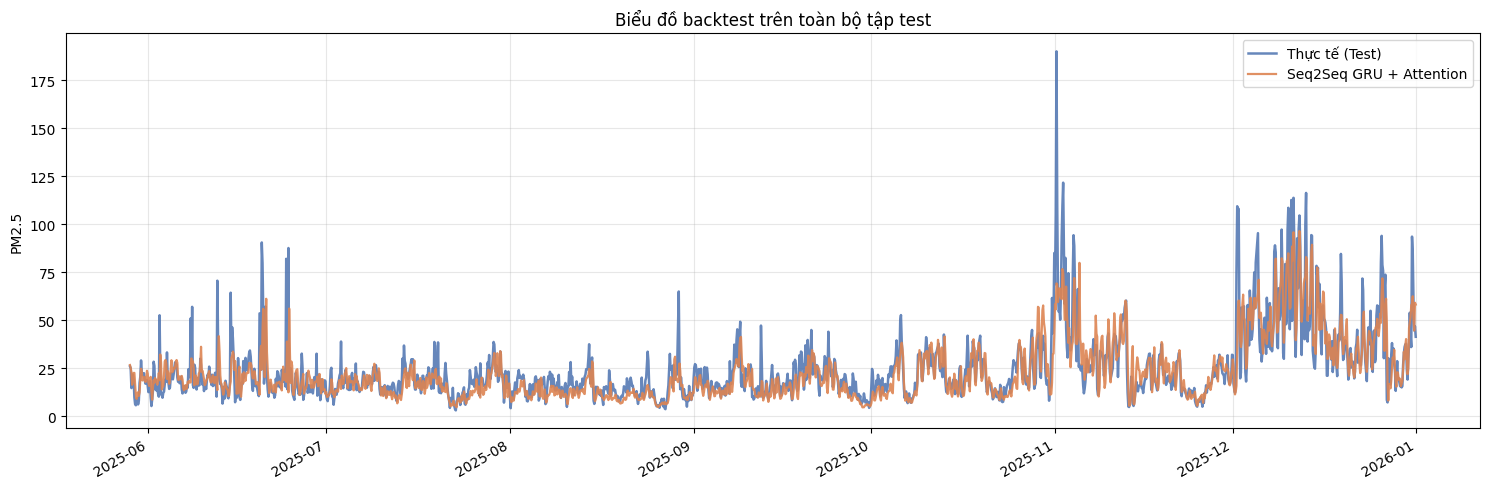

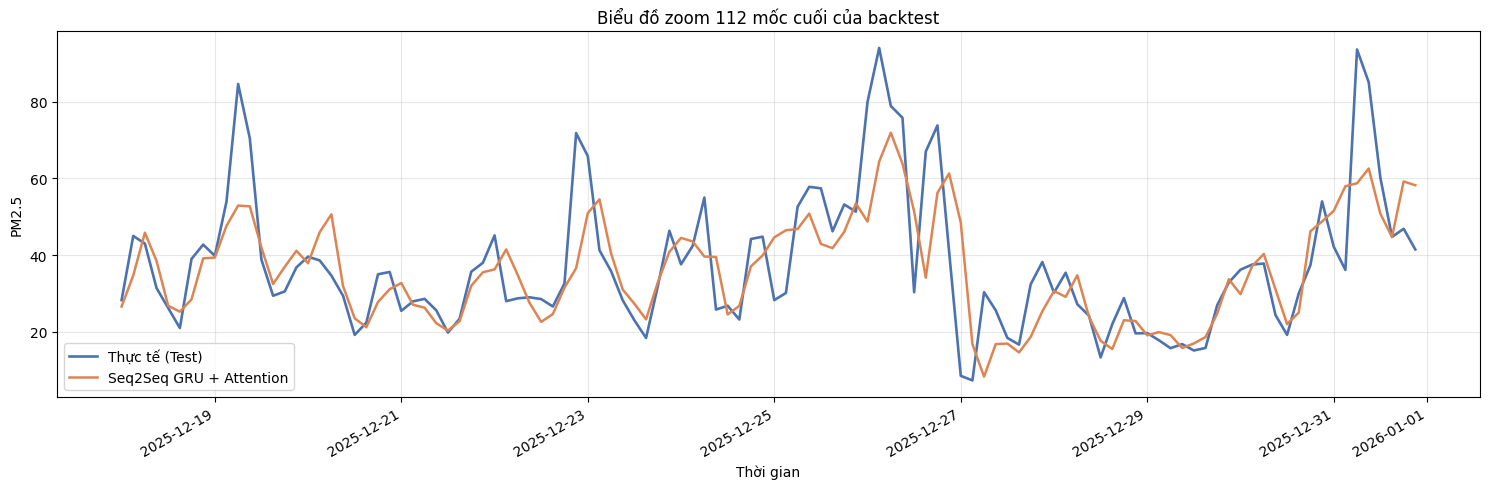

In [21]:
df_raw_rollout = df.copy().sort_index()
df_wf = build_history_feature_frame(df_raw_rollout).dropna().copy()

train_wf = df_wf[:train_end].copy()
val_wf = df_wf[val_start:val_end].copy()
test_wf = df_wf[test_start:].copy()

train_raw = df_raw_rollout[:train_end].copy()
val_raw = df_raw_rollout[val_start:val_end].copy()
test_raw = df_raw_rollout[test_start:].copy()

for feature_set_name in [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]:
    local_cols = candidate_feature_sets[feature_set_name]
    missing_feature_cols = [c for c in local_cols if c not in df_wf.columns]
    if missing_feature_cols:
        raise ValueError(f"Thiếu các cột feature cho {feature_set_name}: {missing_feature_cols}")

MODEL_KWARGS = {
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
MODEL_LABEL = "Seq2Seq GRU + Attention" if MODEL_KWARGS.get("use_attention", False) else "Seq2Seq GRU"

def make_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            min_delta=1e-3,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=LR_REDUCE_PATIENCE,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def resolve_final_epochs(best_epoch_local, floor=FINAL_EPOCH_FLOOR, ceiling=EPOCHS, multiplier=1.35):
    scaled_epoch = int(np.ceil(float(best_epoch_local) * float(multiplier)))
    return min(max(scaled_epoch, int(floor)), int(ceiling))


def split_train_inner_val(train_X_df, train_y_df, inner_val_size):
    min_train_rows = LOOKBACK + CHUNK_HORIZON
    if len(train_X_df) <= inner_val_size + min_train_rows:
        raise ValueError(
            f"Không đủ dữ liệu để tách inner val. Cần > {inner_val_size + min_train_rows} rows, nhận {len(train_X_df)}"
        )
    train_core_X = train_X_df.iloc[:-inner_val_size].copy()
    train_core_y = train_y_df.iloc[:-inner_val_size].copy()
    inner_val_X = train_X_df.iloc[-inner_val_size:].copy()
    inner_val_y = train_y_df.iloc[-inner_val_size:].copy()
    return train_core_X, train_core_y, inner_val_X, inner_val_y


def fit_selector_model(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence cho train hoặc inner val. Kiểm tra lại kích thước dữ liệu và lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_epochs_local = resolve_final_epochs(best_epoch_local)
    print(f"[GRU] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
    }


val_feature_pool = val_wf[feature_cols].copy()
base_train_X = train_wf[feature_cols].copy()
base_train_y = train_wf[["PM25"]].copy()

fold_rows = []
compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model(
        train_core_X, train_core_y, inner_val_X, inner_val_y
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
    model=model,
    history_raw_df=fold_history_raw,
    future_raw_df=fold_eval_raw,
    feature_cols=feature_cols,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    chunk_horizon=CHUNK_HORIZON,
    rollout_horizon=ROLLOUT_HORIZON,
    target_mode=TARGET_TRANSFORM_MODE,
)

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    fold_rows.append(fold_record)

walkforward_df = pd.DataFrame(fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(walkforward_df)

if not walkforward_df.empty:
    val_summary = {
        "mean_rollout_mae": walkforward_df["rollout_mae"].mean(),
        "mean_rollout_rmse": walkforward_df["rollout_rmse"].mean(),
    }

    chunk_mae_cols = sorted(
        [
            col for col in walkforward_df.columns
            if len(col.split("_")) == 3 and col.startswith("chunk_") and col.endswith("_mae")
        ],
        key=lambda col: int(col.split("_")[1]),
    )

    for col in chunk_mae_cols:
        chunk_id = int(col.split("_")[1])
        val_summary[f"mean_chunk_{chunk_id}_mae"] = walkforward_df[col].mean()

    val_summary_df = pd.DataFrame([val_summary])
    print("\n=== Bảng tóm tắt validation ===")
    display(val_summary_df)


# ===== Train trên train+val và backtest trên toàn bộ test =====
DEFAULT_ARTIFACT_ROOT = "/content/drive/MyDrive/pm25_model_registry" if __import__("pathlib").Path("/content/drive/MyDrive").exists() else "/content/model_registry"

def save_variant_bundle(variant, model_name, metrics, bundle_key, export_root=DEFAULT_ARTIFACT_ROOT):
    import json
    import pickle
    import shutil
    from pathlib import Path

    required_keys = ["final_model", "x_scaler", "y_scaler", "feature_cols", "train_full_peak_threshold_t"]
    missing_keys = [key for key in required_keys if key not in variant]
    if missing_keys:
        raise ValueError(f"Variant cá»§a {model_name} thiáº¿u artifact: {missing_keys}")

    export_root = Path(export_root)
    bundle_dir = export_root / bundle_key
    if bundle_dir.exists():
        shutil.rmtree(bundle_dir)
    bundle_dir.mkdir(parents=True, exist_ok=True)

    variant["final_model"].save(bundle_dir / "model.keras")
    with open(bundle_dir / "x_scaler.pkl", "wb") as f:
        pickle.dump(variant["x_scaler"], f)
    with open(bundle_dir / "y_scaler.pkl", "wb") as f:
        pickle.dump(variant["y_scaler"], f)
    with open(bundle_dir / "feature_cols.pkl", "wb") as f:
        pickle.dump(list(variant["feature_cols"]), f)

    config = {
        "model_name": model_name,
        "bundle_key": bundle_key,
        "lookback": int(LOOKBACK),
        "chunk_horizon": int(CHUNK_HORIZON),
        "rollout_horizon": int(ROLLOUT_HORIZON),
        "target_transform_mode": TARGET_TRANSFORM_MODE,
        "feature_cols": list(variant["feature_cols"]),
        "best_epoch": int(variant["best_epoch"]),
        "final_epochs": int(variant.get("final_epochs", variant["best_epoch"])),
        "peak_threshold": float(variant["train_full_peak_threshold_t"]),
    }
    with open(bundle_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)

    metrics_payload = {
        key: (float(value) if hasattr(value, "__float__") else value)
        for key, value in metrics.items()
    }
    with open(bundle_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, ensure_ascii=False, indent=2)

    if "rollout_summary" in variant and "timeline_df" in variant["rollout_summary"]:
        variant["rollout_summary"]["timeline_df"].to_csv(bundle_dir / "test_timeline.csv", index=False)

    zip_path = shutil.make_archive(str(bundle_dir), "zip", bundle_dir)
    print(f"Saved bundle for {model_name}: {bundle_dir}")
    return str(bundle_dir), zip_path

train_val_feature_df = pd.concat([train_wf, val_wf], axis=0)
train_val_raw = pd.concat([train_raw, val_raw], axis=0)
test_backtest_raw = test_raw.copy()
test_rollout_raw = test_backtest_raw.copy()

if len(test_backtest_raw) < CHUNK_HORIZON:
    raise ValueError("Không đủ dữ liệu test để backtest.")

test_variant = fit_test_variant(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

best_epoch_test = test_variant["best_epoch"]
peak_threshold_test_train = test_variant["train_peak_threshold_t"]
peak_threshold_test_full = test_variant["train_full_peak_threshold_t"]
test_eval_summary = test_variant["rollout_summary"]
test_timeline_df = test_eval_summary["timeline_df"].copy()
test_chunk_metrics_df = test_eval_summary["chunk_metrics_df"].copy()
test_window_metrics_df = test_eval_summary["window_metrics_df"].copy()
test_rollout_metrics = test_eval_summary["rollout_metrics"]
test_bundle_dir, test_bundle_zip = save_variant_bundle(
    variant=test_variant,
    model_name=MODEL_LABEL,
    metrics=test_rollout_metrics,
    bundle_key="seq2seq_gru_attention" if MODEL_KWARGS.get("use_attention", False) else "seq2seq_gru",
)

test_metrics_df = pd.DataFrame([
    {
        "best_epoch": best_epoch_test,
        "test_rows": len(test_timeline_df),
        "n_backtest_windows": test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": test_rollout_metrics["mae"],
        "test_rmse": test_rollout_metrics["rmse"],
        "test_mape": test_rollout_metrics["mape"],
        "test_peak_mae": test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": peak_threshold_test_train,
        "train_val_peak_threshold_t": peak_threshold_test_full,
    }
])

test_report_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "test_rows": len(test_timeline_df),
        "n_backtest_windows": test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": test_rollout_metrics["mae"],
        "rmse": test_rollout_metrics["rmse"],
        "MAPE": test_rollout_metrics["mape"],
        "best_epoch": best_epoch_test,
    }
])

print("\n=== Chỉ số backtest trên toàn bộ tập test ===")
display(test_metrics_df)

print("\n=== Chỉ số theo từng cửa sổ backtest ===")
display(test_window_metrics_df)

print("\n=== Chỉ số theo từng chunk trong backtest ===")
display(test_chunk_metrics_df)

print("\n=== Bảng tổng hợp kết quả ===")
display(test_report_df)

plot_df = test_timeline_df.copy()

plt.figure(figsize=(15, 5))
plt.plot(plot_df["timestamp"], plot_df["y_true"], label="Thực tế (Test)", linewidth=1.8, color="#4C72B0", alpha=0.85)
plt.plot(plot_df["timestamp"], plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.6, color="#DD8452", alpha=0.9)

plt.title("Biểu đồ backtest trên toàn bộ tập test")
plt.xlabel("")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

zoom_n = min(len(plot_df), int(14 * 24 / STEP_HOURS))
zoom_plot_df = plot_df.tail(zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(zoom_plot_df["timestamp"], zoom_plot_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(zoom_plot_df["timestamp"], zoom_plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")
plt.title(f"Biểu đồ zoom {zoom_n} mốc cuối của backtest")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Mô hình CNN-GRU

CNN_GRU_MODEL_KWARGS sẵn sàng: {'conv_filters': (64, 128), 'kernel_size': 3, 'pool_size': 1, 'gru_units': (128, 64), 'dense_units': 128, 'dropout': 0.1, 'recurrent_dropout': 0.0, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0, 'use_attention': True}
CNN_GRU_MODEL_LABEL: CNN-GRU + Attention

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 33: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 32: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00034999998752

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,8.888098,11.829016,28.358225,23.428335,54.667333,1.272260,...,18.676871,6.848186,12.161003,12.161003,112.255414,12.161003,4.531466,4.531466,42.482495,4.531466
1,2,8004,56,24,5.413565,7.266435,27.262482,10.253358,24.934000,1.270774,...,7.550912,1.271070,1.815551,1.815551,10.276703,1.815551,0.107007,0.107007,0.635684,0.107007
2,3,8028,56,24,10.652546,12.834548,29.224505,17.697709,75.279167,1.269296,...,1.126450,0.586655,19.431114,19.431114,126.945429,19.431114,13.792180,13.792180,101.562444,13.792180
3,4,8052,56,24,8.063656,10.577468,27.672869,15.513929,48.290667,1.268924,...,3.338847,1.332200,4.373293,4.373293,15.697390,4.373293,5.990897,5.990897,25.572981,5.990897



=== CNN-GRU validation summary ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,8.254466,10.626867,4.10938,8.454792,14.398828



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 30: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 4.374999844003469e-05.
[CNN-GRU] selector best_epoch=14, final_epochs=19
Saved bundle for CNN-GRU + Attention: /content/model_registry/cnn_gru_attention

=== Kết quả backtest CNN-GRU trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.578378,4.881311,29.060255,5.015221,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,6.576895,9.789834,41.127967,20.384639,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,4.066476,4.812465,20.737048,6.513915,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,7.071965,11.834508,28.168929,24.159763,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,4.950952,12.347152,17.381050,23.998528,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,7.546058,10.190194,19.702645,19.254676,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,7.770109,11.158827,20.697468,23.120570,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,15.371123,18.780624,50.893667,29.439385,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,3.593120,4.827765,14.109489,6.477128,37.720000



=== Kết quả CNN-GRU theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,2.321559,2.321559,8.890319,2.321559,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,2.268885,2.268885,9.036981,2.268885,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,10.625991,10.625991,71.894392,10.625991,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,0.095006,0.095006,0.480313,0.095006,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,2.838837,2.838837,13.002307,2.838837,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,29.596483,29.596483,34.792104,29.596483,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,15.278438,15.278438,25.379465,15.278438,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,4.704675,4.704675,10.517156,4.704675,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,0.325628,0.325628,0.694796,0.325628,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của CNN-GRU ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,CNN-GRU + Attention,1735,73,24,1,6.640455,11.085433,26.962497,14


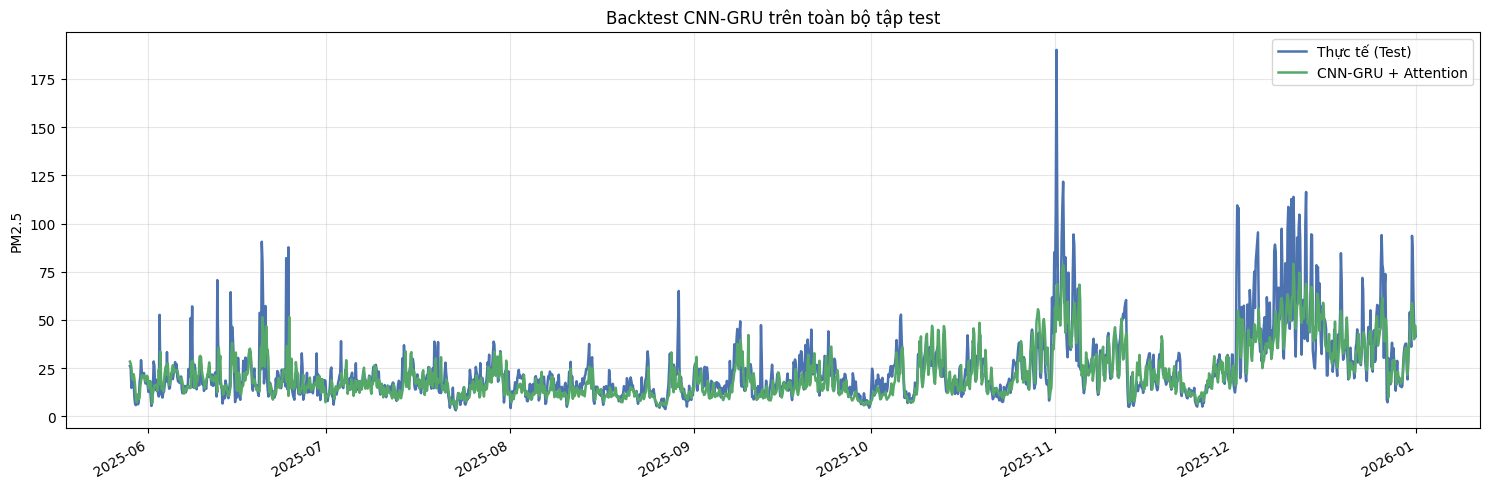

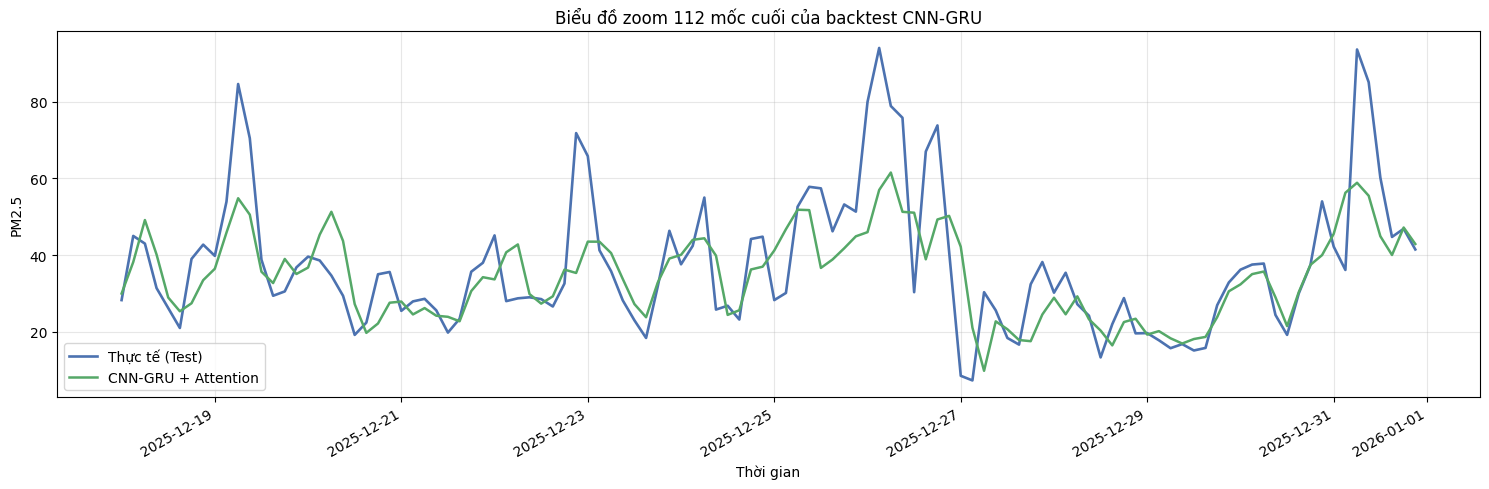

In [ ]:
# Mô hình CNN-GRU
def build_cnn_gru_model(
    lookback,
    n_features,
    horizon,
    conv_filters=(64, 64),
    kernel_size=5,
    pool_size=2,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=5e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(conv_filters, int):
        conv_filters = (conv_filters,)

    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="cnn_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="cnn_decoder_inputs")

    x_enc = encoder_inputs
    for i, filters in enumerate(conv_filters, start=1):
        x_enc = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"encoder_conv_{i}",
        )(x_enc)
        x_enc = tf.keras.layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same",
            name=f"encoder_pool_{i}",
        )(x_enc)
        x_enc = tf.keras.layers.Dropout(dropout, name=f"encoder_conv_dropout_{i}")(x_enc)

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_first_units = decoder_units[0]
    decoder_last_units = decoder_units[-1]

    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="cnn_encoder_gru",
    )(x_enc)

    if encoder_units != decoder_first_units:
        decoder_initial_state = tf.keras.layers.Dense(
            decoder_first_units,
            activation="tanh",
            kernel_regularizer=regularizer,
            name="cnn_decoder_init_projection",
        )(encoder_state)
    else:
        decoder_initial_state = encoder_state

    x = decoder_inputs
    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"cnn_decoder_gru_{i}",
        )(
            x,
            initial_state=[decoder_initial_state] if i == 1 else None,
        )

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="cnn_encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="cnn_temporal_attention")(
            [decoder_outputs, attention_values]
        )
        x = tf.keras.layers.Concatenate(name="cnn_decoder_attention_concat")(
            [decoder_outputs, attention_context]
        )
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="cnn_time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="cnn_decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="cnn_time_distributed_output",
    )(x)

    outputs = tf.keras.layers.Reshape((horizon,), name="cnn_forecast_output")(x)

    model_name = "cnn_gru_attention" if use_attention else "cnn_gru"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model




CNN_GRU_MODEL_KWARGS = {
    "conv_filters": (64, 128),
    "kernel_size": 3,
    "pool_size": 1,
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.10,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}

CNN_GRU_MODEL_LABEL = "CNN-GRU + Attention" if CNN_GRU_MODEL_KWARGS.get("use_attention", False) else "CNN-GRU"
print("CNN_GRU_MODEL_KWARGS sẵn sàng:", CNN_GRU_MODEL_KWARGS)
print("CNN_GRU_MODEL_LABEL:", CNN_GRU_MODEL_LABEL)

# ===== CNN-GRU walk-forward validation + hold-out test (separate variables) =====
def fit_selector_model_cnn_gru(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = CNN_GRU_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho CNN-GRU. Vui lòng kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_cnn_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_cnn_gru(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = CNN_GRU_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho CNN-GRU.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_cnn_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_cnn_gru(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs=None, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_cnn_gru(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_epochs_local = resolve_final_epochs(best_epoch_local)
    print(f"[CNN-GRU] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_cnn_gru(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
    }


cnn_gru_fold_rows = []
cnn_gru_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_cnn_gru(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=CNN_GRU_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )


    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    cnn_gru_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    cnn_gru_fold_rows.append(fold_record)

cnn_gru_walkforward_df = pd.DataFrame(cnn_gru_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ")

display(cnn_gru_walkforward_df)

if not cnn_gru_walkforward_df.empty:
    cnn_gru_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": cnn_gru_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": cnn_gru_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": cnn_gru_walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": cnn_gru_walkforward_df["chunk_2_mae"].mean(),
            "mean_chunk_3_mae": cnn_gru_walkforward_df["chunk_3_mae"].mean(),
        }
    ])
    print()
    print("=== CNN-GRU validation summary ===")
    display(cnn_gru_val_summary_df)


cnn_gru_test_variant = fit_test_variant_cnn_gru(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=CNN_GRU_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

cnn_gru_best_epoch_test = cnn_gru_test_variant["best_epoch"]
cnn_gru_peak_threshold_test_train = cnn_gru_test_variant["train_peak_threshold_t"]
cnn_gru_peak_threshold_test_full = cnn_gru_test_variant["train_full_peak_threshold_t"]
cnn_gru_test_eval_summary = cnn_gru_test_variant["rollout_summary"]
cnn_gru_test_timeline_df = cnn_gru_test_eval_summary["timeline_df"].copy()
cnn_gru_test_chunk_metrics_df = cnn_gru_test_eval_summary["chunk_metrics_df"].copy()
cnn_gru_test_window_metrics_df = cnn_gru_test_eval_summary["window_metrics_df"].copy()
cnn_gru_test_rollout_metrics = cnn_gru_test_eval_summary["rollout_metrics"]
cnn_gru_bundle_dir, cnn_gru_bundle_zip = save_variant_bundle(
    variant=cnn_gru_test_variant,
    model_name=CNN_GRU_MODEL_LABEL,
    metrics=cnn_gru_test_rollout_metrics,
    bundle_key="cnn_gru_attention" if CNN_GRU_MODEL_KWARGS.get("use_attention", False) else "cnn_gru",
)

cnn_gru_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": cnn_gru_best_epoch_test,
        "test_rows": len(cnn_gru_test_timeline_df),
        "n_backtest_windows": cnn_gru_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": cnn_gru_test_rollout_metrics["mae"],
        "test_rmse": cnn_gru_test_rollout_metrics["rmse"],
        "test_mape": cnn_gru_test_rollout_metrics["mape"],
        "test_peak_mae": cnn_gru_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": cnn_gru_peak_threshold_test_train,
        "train_val_peak_threshold_t": cnn_gru_peak_threshold_test_full,
    }
])

cnn_gru_test_report_df = pd.DataFrame([
    {
        "model": CNN_GRU_MODEL_LABEL,
        "test_rows": len(cnn_gru_test_timeline_df),
        "n_backtest_windows": cnn_gru_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": cnn_gru_test_rollout_metrics["mae"],
        "rmse": cnn_gru_test_rollout_metrics["rmse"],
        "MAPE": cnn_gru_test_rollout_metrics["mape"],
        "best_epoch": cnn_gru_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest CNN-GRU trên toàn bộ tập test ===")
display(cnn_gru_test_metrics_df)
print()

print("=== Kết quả CNN-GRU theo từng cửa sổ backtest ===")
display(cnn_gru_test_window_metrics_df)
print()

print("=== Kết quả CNN-GRU theo từng chunk trong backtest ===")
display(cnn_gru_test_chunk_metrics_df)
print()

print("=== Bảng tóm tắt kết quả của CNN-GRU ===")
display(cnn_gru_test_report_df)

if "test_report_df" in globals() and not test_report_df.empty:
    cnn_gru_compare_report_df = pd.concat(
        [test_report_df.copy(), cnn_gru_test_report_df.copy()],
        ignore_index=True,
    )
    print()


cnn_gru_plot_df = cnn_gru_test_timeline_df.copy()
plt.figure(figsize=(15, 5))
plt.plot(cnn_gru_plot_df["timestamp"], cnn_gru_plot_df["y_true"], label="Thực tế (Test)", linewidth=1.8, color="#4C72B0")
plt.plot(cnn_gru_plot_df["timestamp"], cnn_gru_plot_df["y_pred"], label=CNN_GRU_MODEL_LABEL, linewidth=1.8, color="#55A868")

plt.title("Backtest CNN-GRU trên toàn bộ tập test")
plt.xlabel("")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

cnn_gru_zoom_n = min(len(cnn_gru_plot_df), int(14 * 24 / STEP_HOURS))
cnn_gru_zoom_df = cnn_gru_plot_df.tail(cnn_gru_zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(cnn_gru_zoom_df["timestamp"], cnn_gru_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(cnn_gru_zoom_df["timestamp"], cnn_gru_zoom_df["y_pred"], label=CNN_GRU_MODEL_LABEL, linewidth=1.8, color="#55A868")
plt.title(f"Biểu đồ zoom {cnn_gru_zoom_n} mốc cuối của backtest CNN-GRU")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 13. Huấn luyện và đánh giá mô hình Seq2Seq LSTM




LSTM_MODEL_KWARGS sẵn sàng: {'lstm_units': (128, 64), 'dense_units': 128, 'dropout': 0.15, 'recurrent_dropout': 0.0, 'learning_rate': 0.0002, 'l2_reg': 1e-05, 'clipnorm': 1.0, 'use_attention': True}
LSTM_MODEL_LABEL: Seq2Seq LSTM + Attention

Epoch 40: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 48: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 29: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 37: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 45: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
=== Đánh giá walk-forward: rollout mô phỏng triển khai 2

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,9.393203,12.797687,27.486384,28.856184,54.667333,1.272260,...,26.405321,9.681951,10.535310,10.535310,97.249015,10.535310,0.975436,0.975436,9.144715,0.975436
1,2,8004,56,24,4.997556,6.273614,26.607973,5.488135,24.934000,1.270774,...,22.590471,3.802729,0.089758,0.089758,0.508065,0.089758,5.415267,5.415267,32.169900,5.415267
2,3,8028,56,24,7.515241,10.342602,18.997615,9.521617,75.279167,1.269296,...,8.571173,4.463867,18.314750,18.314750,119.652115,18.314750,0.648612,0.648612,4.776233,0.648612
3,4,8052,56,24,8.153183,9.555701,24.709211,13.940887,48.290667,1.268924,...,29.475160,11.760589,3.024470,3.024470,10.855959,3.024470,7.456223,7.456223,31.827931,7.456223



=== Bảng tóm tắt validation của LSTM ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae,mean_chunk_4_mae,mean_chunk_5_mae,mean_chunk_6_mae,mean_chunk_7_mae,mean_chunk_8_mae,...,mean_chunk_15_mae,mean_chunk_16_mae,mean_chunk_17_mae,mean_chunk_18_mae,mean_chunk_19_mae,mean_chunk_20_mae,mean_chunk_21_mae,mean_chunk_22_mae,mean_chunk_23_mae,mean_chunk_24_mae
0,7.514796,9.742401,5.100462,6.939262,12.422201,8.391995,5.5901,5.014356,2.919867,3.061379,...,5.219126,3.289315,7.678607,16.236185,6.066785,12.742691,7.837258,7.427284,7.991072,3.623885



Epoch 18: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
[LSTM] selector best_epoch=10, final_epochs=14
Saved bundle for Seq2Seq LSTM + Attention: /content/model_registry/seq2seq_lstm_attention

=== Kết quả backtest LSTM trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,2.975270,4.279988,24.411029,3.368030,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,6.228994,10.406542,36.053238,18.553904,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,2.905080,4.733541,14.698460,5.582822,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,7.564372,12.431987,30.266767,25.031751,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,6.583400,13.359321,24.994102,29.486002,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,5.345972,7.906701,14.098980,13.185699,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,8.135098,11.571069,23.782827,16.337646,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,12.527789,16.464047,42.702296,16.552689,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,4.862316,6.477692,18.833011,8.381257,37.720000



=== Kết quả LSTM theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,1.674140,1.674140,6.411053,1.674140,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,0.675050,0.675050,2.688727,0.675050,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,8.858347,8.858347,59.934690,8.858347,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,3.939625,3.939625,19.917214,3.939625,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,0.065637,0.065637,0.300626,0.065637,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,3.170960,3.170960,3.727618,3.170960,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,0.043878,0.043878,0.072887,0.043878,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,0.435209,0.435209,0.972896,0.435209,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,2.393965,2.393965,5.108034,2.393965,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của LSTM ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,mape,best_epoch
0,Seq2Seq LSTM + Attention,1735,73,24,1,5.708628,9.909685,24.13446,10


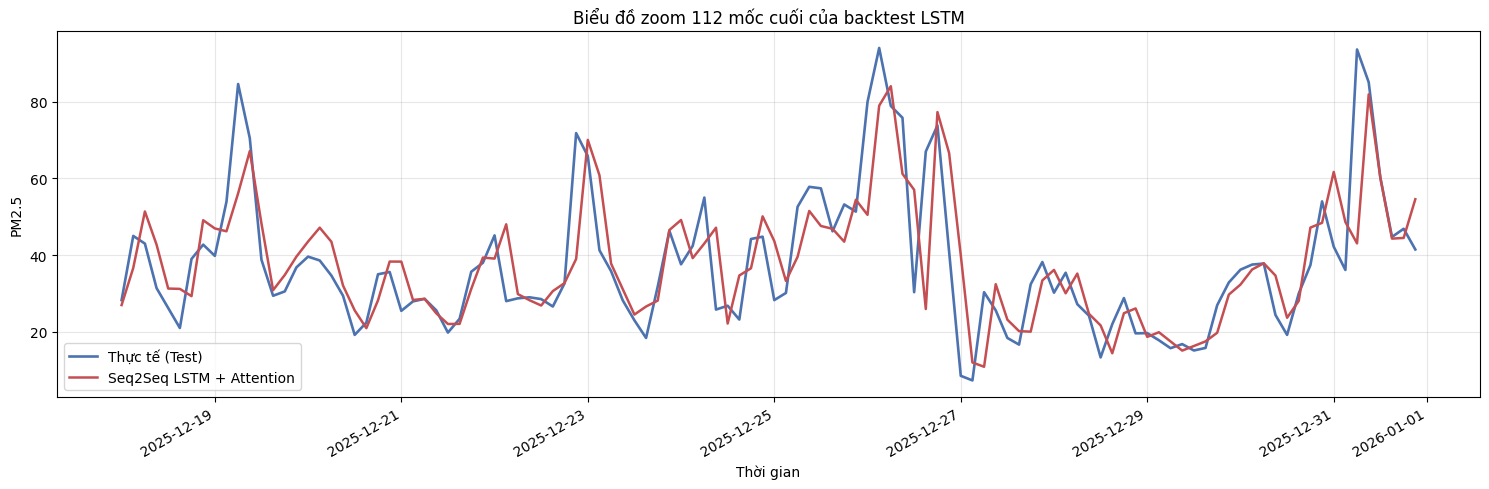

In [ ]:
# ===== Seq2Seq LSTM walk-forward validation + hold-out test =====
def build_lstm_model(
    lookback,
    n_features,
    horizon,
    lstm_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=2e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(lstm_units, int):
        lstm_units = (lstm_units, max(lstm_units // 2, 32))
    elif len(lstm_units) == 1:
        lstm_units = (lstm_units[0], max(lstm_units[0] // 2, 32))

    encoder_units = lstm_units[0]
    decoder_units = tuple(lstm_units[1:]) if len(lstm_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_first_units = decoder_units[0]
    decoder_last_units = decoder_units[-1]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="lstm_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="lstm_decoder_inputs")

    encoder_outputs, encoder_state_h, encoder_state_c = tf.keras.layers.LSTM(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_lstm",
    )(encoder_inputs)

    if encoder_units != decoder_first_units:
        decoder_init_h = tf.keras.layers.Dense(decoder_first_units, activation="tanh", kernel_regularizer=regularizer, name="lstm_decoder_init_h")(encoder_state_h)
        decoder_init_c = tf.keras.layers.Dense(decoder_first_units, activation="tanh", kernel_regularizer=regularizer, name="lstm_decoder_init_c")(encoder_state_c)
    else:
        decoder_init_h = encoder_state_h
        decoder_init_c = encoder_state_c

    x = decoder_inputs
    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.LSTM(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_lstm_{i}",
        )(x, initial_state=[decoder_init_h, decoder_init_c] if i == 1 else None)

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(decoder_last_units, kernel_regularizer=regularizer, name="lstm_encoder_attention_projection")(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="lstm_temporal_attention")([decoder_outputs, attention_values])
        x = tf.keras.layers.Concatenate(name="lstm_decoder_attention_concat")([decoder_outputs, attention_context])
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(dense_units, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizer),
            name="lstm_time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="lstm_decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name="lstm_time_distributed_output")(x)
    forecast_delta = tf.keras.layers.Reshape((horizon,), name="lstm_forecast_delta")(x)
    decoder_baseline = tf.keras.layers.Reshape((horizon,), name="lstm_decoder_baseline")(decoder_inputs)
    outputs = tf.keras.layers.Add(name="lstm_forecast_output")([forecast_delta, decoder_baseline])

    model_name = "seq2seq_lstm_attention" if use_attention else "seq2seq_lstm"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm), loss=loss_fn, metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model



LSTM_MODEL_KWARGS = {
    "lstm_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 2e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
LSTM_MODEL_LABEL = "Seq2Seq LSTM + Attention" if LSTM_MODEL_KWARGS.get("use_attention", False) else "Seq2Seq LSTM"
print("LSTM_MODEL_KWARGS sẵn sàng:", LSTM_MODEL_KWARGS)
print("LSTM_MODEL_LABEL:", LSTM_MODEL_LABEL)


def fit_selector_model_lstm(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = LSTM_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho LSTM. Vui lòng kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    lstm_peak_weight = float(PEAK_WEIGHT)
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=lstm_peak_weight,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_lstm_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_lstm(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = LSTM_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho LSTM.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    lstm_peak_weight = float(PEAK_WEIGHT)
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=lstm_peak_weight,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_lstm_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_lstm(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs=None, selector_epochs=EPOCHS, rolling_policy=ROLLING_POLICY):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_lstm(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_epochs_local = resolve_final_epochs(best_epoch_local)
    print(f"[LSTM] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_lstm(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        rolling_policy=rolling_policy,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
    }


rollout_runner = get_rollout_runner(ROLLING_POLICY)

lstm_fold_rows = []
lstm_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    selector_model, history, best_epoch, _, _, peak_threshold_train = fit_selector_model_lstm(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=LSTM_MODEL_KWARGS,
    )

    final_epochs = resolve_final_epochs(best_epoch)
    final_model, x_scaler, y_scaler, peak_threshold_full = fit_full_history_model_lstm(
        fold_history_X,
        fold_history_y,
        epochs=final_epochs,
        model_kwargs=LSTM_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = rollout_runner(
        model=final_model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "best_epoch": best_epoch,
        "final_epochs": final_epochs,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        if chunk_id in chunk_metrics_df.index:
            chunk_metrics = chunk_metrics_df.loc[chunk_id]
            fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
            fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
            fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
            fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    lstm_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    lstm_fold_rows.append(fold_record)

lstm_walkforward_df = pd.DataFrame(lstm_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ")
display(lstm_walkforward_df)

if not lstm_walkforward_df.empty:
    summary_row = {
        "mean_rollout_mae": lstm_walkforward_df["rollout_mae"].mean(),
        "mean_rollout_rmse": lstm_walkforward_df["rollout_rmse"].mean(),
    }
    for chunk_id in range(1, N_CHUNKS + 1):
        col = f"chunk_{chunk_id}_mae"
        summary_row[f"mean_chunk_{chunk_id}_mae"] = (
            lstm_walkforward_df[col].mean() if col in lstm_walkforward_df.columns else np.nan
        )

    lstm_val_summary_df = pd.DataFrame([summary_row])
    print()
    print("=== Bảng tóm tắt validation của LSTM ===")
    display(lstm_val_summary_df)

lstm_variant = fit_test_variant_lstm(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=LSTM_MODEL_KWARGS,
    selector_epochs=EPOCHS,
    rolling_policy=ROLLING_POLICY,
)

lstm_best_epoch_test = lstm_variant["best_epoch"]
lstm_peak_threshold_test_train = lstm_variant["train_peak_threshold_t"]
lstm_peak_threshold_test_full = lstm_variant["train_full_peak_threshold_t"]
lstm_test_eval_summary = lstm_variant["rollout_summary"]
lstm_test_timeline_df = lstm_test_eval_summary["timeline_df"].copy()
lstm_test_chunk_metrics_df = lstm_test_eval_summary["chunk_metrics_df"].copy()
lstm_test_window_metrics_df = lstm_test_eval_summary["window_metrics_df"].copy()
lstm_test_rollout_metrics = lstm_test_eval_summary["rollout_metrics"]
lstm_bundle_dir, lstm_bundle_zip = save_variant_bundle(
    variant=lstm_variant,
    model_name=LSTM_MODEL_LABEL,
    metrics=lstm_test_rollout_metrics,
    bundle_key="seq2seq_lstm_attention" if LSTM_MODEL_KWARGS.get("use_attention", False) else "seq2seq_lstm",
)

lstm_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": lstm_best_epoch_test,
        "test_rows": len(lstm_test_timeline_df),
        "n_backtest_windows": lstm_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": lstm_test_rollout_metrics["mae"],
        "test_rmse": lstm_test_rollout_metrics["rmse"],
        "test_mape": lstm_test_rollout_metrics["mape"],
        "test_peak_mae": lstm_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": lstm_peak_threshold_test_train,
        "train_val_peak_threshold_t": lstm_peak_threshold_test_full,
    }
])

lstm_test_report_df = pd.DataFrame([
    {
        "model": LSTM_MODEL_LABEL,
        "test_rows": len(lstm_test_timeline_df),
        "n_backtest_windows": lstm_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": lstm_test_rollout_metrics["mae"],
        "rmse": lstm_test_rollout_metrics["rmse"],
        "mape": lstm_test_rollout_metrics["mape"],
        "best_epoch": lstm_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest LSTM trên toàn bộ tập test ===")
display(lstm_test_metrics_df)
print()
print("=== Kết quả LSTM theo từng cửa sổ backtest ===")
display(lstm_test_window_metrics_df)
print()
print("=== Kết quả LSTM theo từng chunk trong backtest ===")
display(lstm_test_chunk_metrics_df)
print()
print("=== Bảng tóm tắt kết quả của LSTM ===")
display(lstm_test_report_df)



lstm_zoom_n = min(len(lstm_test_timeline_df), int(14 * 24 / STEP_HOURS))
lstm_zoom_df = lstm_test_timeline_df.tail(lstm_zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(lstm_zoom_df["timestamp"], lstm_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(lstm_zoom_df["timestamp"], lstm_zoom_df["y_pred"], label=LSTM_MODEL_LABEL, linewidth=1.8, color="#C44E52")
plt.title(f"Biểu đồ zoom {lstm_zoom_n} mốc cuối của backtest LSTM")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


### 14. Mô hình TCN

TCN_MODEL_KWARGS ready: {'filters': (32, 64, 96), 'kernel_size': 3, 'dilations': (1, 2, 4), 'dense_units': 64, 'dropout': 0.1, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0}
TCN_MODEL_LABEL: Direct TCN
TCN_MAX_FOLDS / TCN_SELECTOR_EPOCHS / TCN_FINAL_EPOCH_CAP: 2 30 36
=== Đánh giá walk-forward: rollout mô phỏng triển khai 24 bước = 1 x 24 


,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,9.069357,11.482124,32.332546,21.299454,54.667333,1.272260,...,7.664242,2.810222,19.249891,19.249891,177.691298,19.249891,1.572097,1.572097,14.738411,1.572097
1,2,8004,56,24,6.604586,9.531081,32.447830,15.714660,24.934000,1.270774,...,23.210876,3.907164,0.349869,0.349869,1.980389,0.349869,1.339389,1.339389,7.956763,1.339389



=== Tổng kết validation của TCN ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae,mean_chunk_4_mae,mean_chunk_5_mae,mean_chunk_6_mae,mean_chunk_7_mae,mean_chunk_8_mae,...,mean_chunk_15_mae,mean_chunk_16_mae,mean_chunk_17_mae,mean_chunk_18_mae,mean_chunk_19_mae,mean_chunk_20_mae,mean_chunk_21_mae,mean_chunk_22_mae,mean_chunk_23_mae,mean_chunk_24_mae
0,7.836971,10.506602,11.47365,13.29238,15.923362,6.251334,2.947331,3.330139,6.543063,3.119904,...,8.25297,4.751528,5.292181,12.804371,2.776373,12.90172,10.200635,3.358693,9.79988,1.455743


[TCN] selector best_epoch=30, final_epochs=33
Saved bundle for Direct TCN: /content/model_registry/direct_tcn

=== Kết quả backtest TCN trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.128266,4.224157,23.414020,3.559462,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,6.950867,11.466332,40.627584,19.257027,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,2.932993,4.754110,14.359435,6.809369,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,7.841245,13.219656,31.323115,23.961734,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,6.875490,14.484813,24.309597,32.373876,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,6.106663,8.405271,17.145645,10.232256,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,7.850847,11.149735,22.615091,13.819697,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,13.768109,17.734597,44.240521,21.512971,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,5.546900,6.870545,20.575916,11.437426,37.720000



=== Chỉ số TCN theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,2.475356,2.475356,9.479282,2.475356,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,0.556721,0.556721,2.217422,0.556721,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,9.508501,9.508501,64.333564,9.508501,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,5.040257,5.040257,25.481581,5.040257,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,1.471600,1.471600,6.740152,1.471600,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,0.983171,0.983171,1.155765,0.983171,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,16.208598,16.208598,26.924582,16.208598,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,15.496027,15.496027,34.640895,15.496027,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,3.632360,3.632360,7.750413,3.632360,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của TCN ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,mape,best_epoch
0,Direct TCN,1735,73,24,1,5.959188,10.430782,25.634377,30


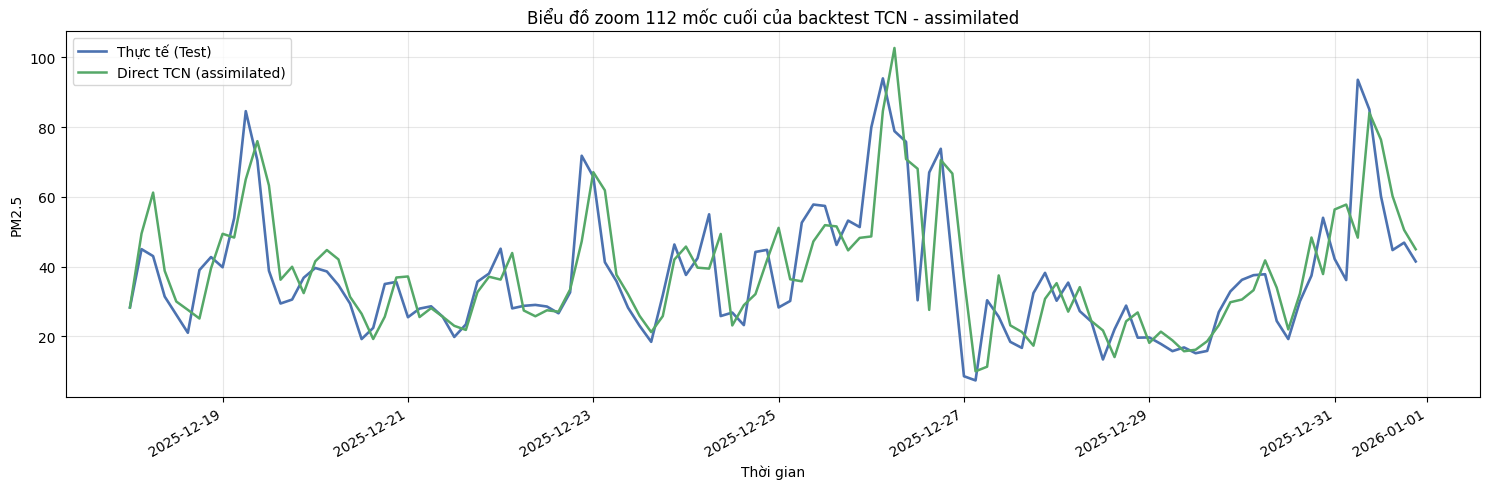

In [38]:
# ===== Seq2Seq TCN walk-forward validation + full-test backtest =====

def make_sequences_clean(X, y, lookback, horizon):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]

        last_y = y[i + lookback - 1]
        decoder_seed = np.full((horizon, 1), last_y, dtype=np.float32)

        decoder_seq.append(decoder_seed)
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )


def prepare_train_eval_sequences_clean(
    train_X_df,
    train_y_df,
    eval_X_df,
    eval_y_df,
    lookback=72,
    horizon=72,
    target_mode="log1p",
):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df phải có ít nhất `lookback` hàng")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences_clean(
        X_train_scaled, y_train_scaled, lookback=lookback, horizon=horizon
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])
    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences_clean(
        X_context, y_context, lookback=lookback, horizon=horizon
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout, l2_reg=0.0, name="tcn_block"):
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    shortcut = x

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=f"{name}_conv1",
    )(x)
    y = tf.keras.layers.Dropout(dropout, name=f"{name}_drop1")(y)
    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=f"{name}_conv2",
    )(y)
    y = tf.keras.layers.Dropout(dropout, name=f"{name}_drop2")(y)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            kernel_regularizer=regularizer,
            name=f"{name}_proj",
        )(shortcut)

    added = tf.keras.layers.Add(name=f"{name}_add")([shortcut, y])
    return tf.keras.layers.Activation("relu", name=f"{name}_relu")(added)



def build_tcn_direct_model(
    lookback,
    n_features,
    horizon,
    filters=(64, 64, 128),
    kernel_size=3,
    dilations=(1, 2, 4, 8),
    dense_units=128,
    dropout=0.15,
    learning_rate=7e-4,
    loss_fn="mse",
    l2_reg=1e-5,
    clipnorm=1.0,
):
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(
        shape=(lookback, n_features),
        name="tcn_encoder_inputs",
    )

    decoder_inputs = tf.keras.layers.Input(
        shape=(horizon, 1),
        name="tcn_decoder_inputs",
    )

    x = encoder_inputs
    for block_idx, f in enumerate(filters, start=1):
        for d in dilations:
            x = tcn_residual_block(
                x,
                filters=f,
                kernel_size=kernel_size,
                dilation_rate=d,
                dropout=dropout,
                l2_reg=l2_reg,
                name=f"direct_tcn_b{block_idx}_d{d}",
            )

    last_state = tf.keras.layers.Lambda(
        lambda z: z[:, -1, :],
        name="last_tcn_state",
    )(x)
    avg_state = tf.keras.layers.GlobalAveragePooling1D(name="avg_tcn_state")(x)
    max_state = tf.keras.layers.GlobalMaxPooling1D(name="max_tcn_state")(x)

    x = tf.keras.layers.Concatenate(name="tcn_context_concat")(
        [last_state, avg_state, max_state]
    )

    if dense_units:
        x = tf.keras.layers.Dense(
            dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name="tcn_dense_1",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="tcn_dropout")(x)

    forecast_delta = tf.keras.layers.Dense(
        horizon,
        kernel_regularizer=regularizer,
        name="forecast_delta",
    )(x)

    decoder_baseline = tf.keras.layers.Reshape(
        (horizon,),
        name="tcn_decoder_baseline",
    )(decoder_inputs)

    outputs = tf.keras.layers.Add(name="forecast_output")(
        [forecast_delta, decoder_baseline]
    )

    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="direct_multi_horizon_tcn",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=clipnorm,
        ),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model






TCN_MODEL_KWARGS = {
    "filters": (32, 64, 96),
    "kernel_size": 3,
    "dilations": (1, 2, 4),
    "dense_units": 64,
    "dropout": 0.10,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
}

TCN_MODEL_LABEL = "Direct TCN"
TCN_MAX_FOLDS = min(MAX_FOLDS, 2)
TCN_SELECTOR_EPOCHS = min(EPOCHS, 30)
TCN_FINAL_EPOCH_CAP = min(EPOCHS, 36)

print("TCN_MODEL_KWARGS ready:", TCN_MODEL_KWARGS)
print("TCN_MODEL_LABEL:", TCN_MODEL_LABEL)
print("TCN_MAX_FOLDS / TCN_SELECTOR_EPOCHS / TCN_FINAL_EPOCH_CAP:", TCN_MAX_FOLDS, TCN_SELECTOR_EPOCHS, TCN_FINAL_EPOCH_CAP)


def fit_selector_model_tcn(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = TCN_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences_clean(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho TCN. Kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    tcn_peak_weight = float(PEAK_WEIGHT)
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=tcn_peak_weight,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_tcn_direct_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_tcn(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = TCN_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences_clean(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho TCN.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    tcn_peak_weight = float(PEAK_WEIGHT)
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=tcn_peak_weight,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_tcn_direct_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_tcn(
    feature_cols_local,
    history_feature_df,
    history_raw_df,
    future_raw_df,
    model_kwargs=None,
    selector_epochs=EPOCHS,
    rolling_policy=ROLLING_POLICY,
):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_tcn(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_epochs_local = resolve_final_epochs(best_epoch_local, multiplier=1.10, ceiling=TCN_FINAL_EPOCH_CAP)
    print(f"[TCN] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")

    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_tcn(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        rolling_policy=rolling_policy,
        decoder_rollout="constant_last",
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
    }


rollout_runner = get_rollout_runner(ROLLING_POLICY)

tcn_fold_rows = []
tcn_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > TCN_MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    selector_model, history, best_epoch, _, _, peak_threshold_train = fit_selector_model_tcn(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=TCN_MODEL_KWARGS,
        epochs=TCN_SELECTOR_EPOCHS,
    )

    final_epochs = resolve_final_epochs(best_epoch, multiplier=1.10, ceiling=TCN_FINAL_EPOCH_CAP)
    final_model, x_scaler, y_scaler, peak_threshold_full = fit_full_history_model_tcn(
        fold_history_X,
        fold_history_y,
        epochs=final_epochs,
        model_kwargs=TCN_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = rollout_runner(
        model=final_model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        decoder_rollout="constant_last",
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "best_epoch": best_epoch,
        "final_epochs": final_epochs,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        if chunk_id in chunk_metrics_df.index:
            chunk_metrics = chunk_metrics_df.loc[chunk_id]
            fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
            fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
            fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
            fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    tcn_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    tcn_fold_rows.append(fold_record)

tcn_walkforward_df = pd.DataFrame(tcn_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ")
display(tcn_walkforward_df)

if not tcn_walkforward_df.empty:
    summary_row = {
        "mean_rollout_mae": tcn_walkforward_df["rollout_mae"].mean(),
        "mean_rollout_rmse": tcn_walkforward_df["rollout_rmse"].mean(),
    }
    for chunk_id in range(1, N_CHUNKS + 1):
        col = f"chunk_{chunk_id}_mae"
        summary_row[f"mean_chunk_{chunk_id}_mae"] = (
            tcn_walkforward_df[col].mean() if col in tcn_walkforward_df.columns else np.nan
        )

    tcn_val_summary_df = pd.DataFrame([summary_row])
    print()
    print("=== Tổng kết validation của TCN ===")
    display(tcn_val_summary_df)

tcn_variant = fit_test_variant_tcn(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=TCN_MODEL_KWARGS,
    selector_epochs=TCN_SELECTOR_EPOCHS,
    rolling_policy=ROLLING_POLICY,
)

tcn_best_epoch_test = tcn_variant["best_epoch"]
tcn_peak_threshold_test_train = tcn_variant["train_peak_threshold_t"]
tcn_peak_threshold_test_full = tcn_variant["train_full_peak_threshold_t"]
tcn_test_eval_summary = tcn_variant["rollout_summary"]
tcn_test_timeline_df = tcn_test_eval_summary["timeline_df"].copy()
tcn_test_chunk_metrics_df = tcn_test_eval_summary["chunk_metrics_df"].copy()
tcn_test_window_metrics_df = tcn_test_eval_summary["window_metrics_df"].copy()
tcn_test_rollout_metrics = tcn_test_eval_summary["rollout_metrics"]
tcn_bundle_dir, tcn_bundle_zip = save_variant_bundle(
    variant=tcn_variant,
    model_name=TCN_MODEL_LABEL,
    metrics=tcn_test_rollout_metrics,
    bundle_key="direct_tcn",
)

tcn_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": tcn_best_epoch_test,
        "test_rows": len(tcn_test_timeline_df),
        "n_backtest_windows": tcn_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": tcn_test_rollout_metrics["mae"],
        "test_rmse": tcn_test_rollout_metrics["rmse"],
        "test_mape": tcn_test_rollout_metrics["mape"],
        "test_peak_mae": tcn_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": tcn_peak_threshold_test_train,
        "train_val_peak_threshold_t": tcn_peak_threshold_test_full,
    }
])

tcn_test_report_df = pd.DataFrame([
    {
        "model": TCN_MODEL_LABEL,
        "test_rows": len(tcn_test_timeline_df),
        "n_backtest_windows": tcn_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": tcn_test_rollout_metrics["mae"],
        "rmse": tcn_test_rollout_metrics["rmse"],
        "mape": tcn_test_rollout_metrics["mape"],
        "best_epoch": tcn_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest TCN trên toàn bộ tập test ===")
display(tcn_test_metrics_df)
print()
print("=== Chỉ số TCN theo từng cửa sổ backtest ===")
display(tcn_test_window_metrics_df)
print()
print("=== Chỉ số TCN theo từng chunk trong backtest ===")
display(tcn_test_chunk_metrics_df)
print()
print("=== Bảng tóm tắt kết quả của TCN ===")
display(tcn_test_report_df)

tcn_zoom_n = min(len(tcn_test_timeline_df), int(14 * 24 / STEP_HOURS))
tcn_zoom_df = tcn_test_timeline_df.tail(tcn_zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(tcn_zoom_df["timestamp"], tcn_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(tcn_zoom_df["timestamp"], tcn_zoom_df["y_pred"], label=f"{TCN_MODEL_LABEL} ({ROLLING_POLICY})", linewidth=1.8, color="#55A868")
plt.title(f"Biểu đồ zoom {tcn_zoom_n} mốc cuối của backtest TCN - {ROLLING_POLICY}")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


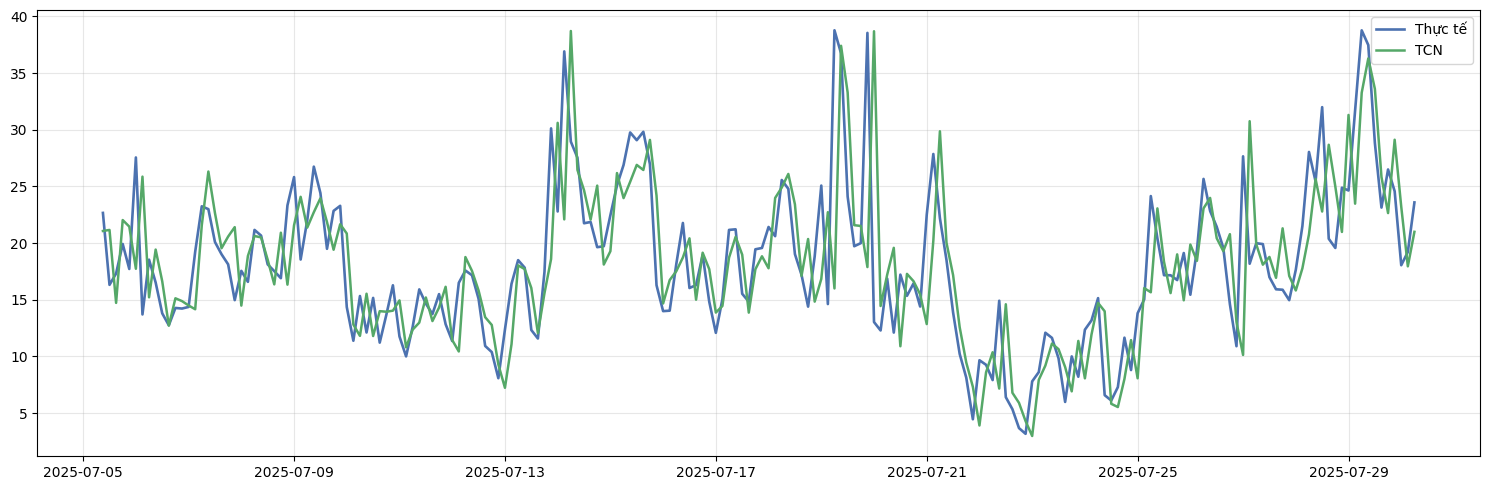

MAE naive: 6.462618223760092 MAE model: 5.961196751416521 improve: 0.501421472343571


In [39]:
start_idx = 300   # mốc bắt đầu (0-based)
length = 200      # số điểm cần xem
zoom_df = tcn_test_timeline_df.iloc[start_idx:start_idx + length]

plot_df = zoom_df.copy()
plot_df["naive_lag1"] = plot_df["y_true"].shift(1)
plt.figure(figsize=(15,5))
plt.plot(plot_df["timestamp"], plot_df["y_true"], label="Thực tế", color="#4C72B0", linewidth=1.9)
plt.plot(plot_df["timestamp"], plot_df["y_pred"], label="TCN", color="#55A868", linewidth=1.8)
# plt.plot(plot_df["timestamp"], plot_df["naive_lag1"], label="Naive (y[t-1])", color="#C44E52", linewidth=1.4, alpha=0.9)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

df = tcn_test_timeline_df.copy().sort_values("timestamp")
naive = df["y_true"].shift(1)

mask = naive.notna()
mae_naive = np.mean(np.abs(df.loc[mask, "y_true"] - naive.loc[mask]))
mae_model = np.mean(np.abs(df.loc[mask, "y_true"] - df.loc[mask, "y_pred"]))
print("MAE naive:", mae_naive, "MAE model:", mae_model, "improve:", mae_naive - mae_model)

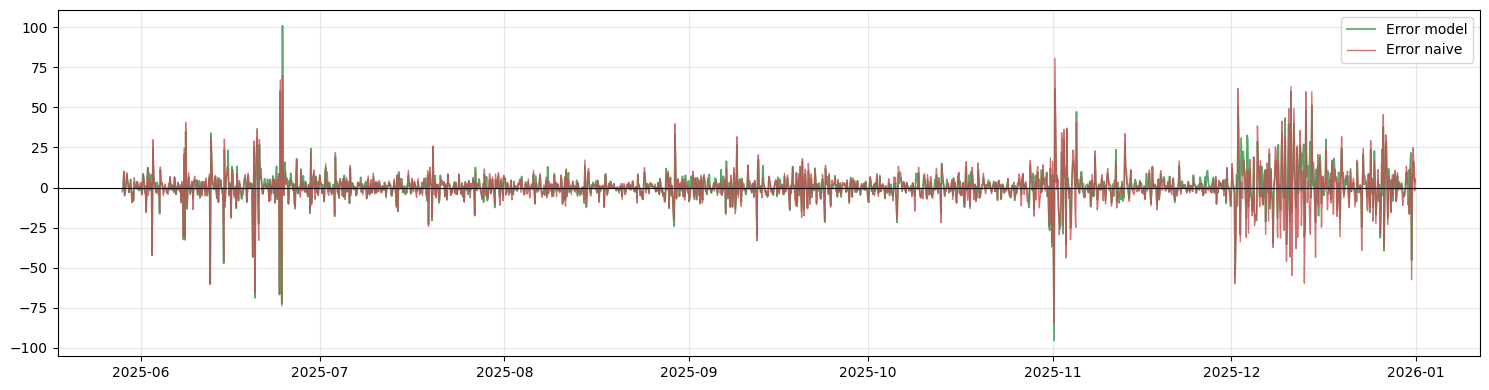

In [40]:
df = tcn_test_timeline_df.copy().sort_values("timestamp")
df["naive"] = df["y_true"].shift(1)

df["err_model"] = df["y_pred"] - df["y_true"]
df["err_naive"] = df["naive"] - df["y_true"]

plt.figure(figsize=(15,4))
plt.plot(df["timestamp"], df["err_model"], label="Error model", color="#55A868", linewidth=1.2)
plt.plot(df["timestamp"], df["err_naive"], label="Error naive", color="#C44E52", linewidth=1.0, alpha=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

DECODER_FUTURE_COLS: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']
TCN_MODEL_KWARGS ready: {'encoder_filters': (32, 64, 96), 'decoder_filters': (32,), 'kernel_size': 3, 'dilations': (1, 2, 4), 'dense_units': 64, 'dropout': 0.1, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0}
TCN_MODEL_LABEL: Seq2Seq TCN + Calendar Decoder
TCN_MAX_FOLDS / TCN_SELECTOR_EPOCHS / TCN_FINAL_EPOCH_CAP: 2 30 36

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 28: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
=== Đánh giá walk-forward: rollout mô phỏng triển khai 24 bước = 1 x 24 ===


,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,10.684123,13.645645,36.515459,23.675093,54.667333,1.272260,...,1.955543,0.717033,19.457756,19.457756,179.610053,19.457756,0.763466,0.763466,7.157494,0.763466
1,2,8004,56,24,6.330394,8.516018,34.581845,9.474014,24.934000,1.270774,...,22.214770,3.739486,2.695474,2.695474,15.257401,2.695474,1.249978,1.249978,7.425609,1.249978



=== Tổng kết validation của TCN ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae,mean_chunk_4_mae,mean_chunk_5_mae,mean_chunk_6_mae,mean_chunk_7_mae,mean_chunk_8_mae,...,mean_chunk_15_mae,mean_chunk_16_mae,mean_chunk_17_mae,mean_chunk_18_mae,mean_chunk_19_mae,mean_chunk_20_mae,mean_chunk_21_mae,mean_chunk_22_mae,mean_chunk_23_mae,mean_chunk_24_mae
0,8.507258,11.080831,7.277649,12.300489,10.161809,7.629309,5.475235,3.634559,6.462268,2.504075,...,8.434026,5.8119,11.07135,14.95332,2.50702,11.84997,11.758291,2.228259,11.076615,1.006722


[TCN] selector best_epoch=29, final_epochs=32
Saved bundle for Seq2Seq TCN + Calendar Decoder: /content/model_registry/seq2seq_tcn_calendar_decoder

=== Kết quả backtest TCN trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.860108,4.589270,28.721107,3.311623,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,6.813268,9.968890,41.562689,18.920454,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,3.130368,4.260889,14.822462,7.243866,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,7.230974,12.173700,28.724210,23.927233,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,5.909609,12.962636,22.411693,22.908875,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,6.342589,9.114420,15.910698,17.946672,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,7.526691,10.331264,21.256464,14.887203,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,13.434654,17.406919,36.886086,21.864814,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,5.734421,8.538270,21.096556,7.848479,37.720000



=== Chỉ số TCN theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,2.323111,2.323111,8.896264,2.323111,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,1.903841,1.903841,7.583008,1.903841,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,8.312991,8.312991,56.244867,8.312991,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,4.160076,4.160076,21.031729,4.160076,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,2.641131,2.641131,12.096784,2.641131,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,25.749453,25.749453,30.269733,25.749453,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,11.720294,11.720294,19.468927,11.720294,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,10.932461,10.932461,24.439183,10.932461,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,4.445335,4.445335,9.485067,4.445335,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của TCN ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,mape,best_epoch
0,Seq2Seq TCN + Calendar Decoder,1735,73,24,1,5.630072,9.447253,23.843173,29


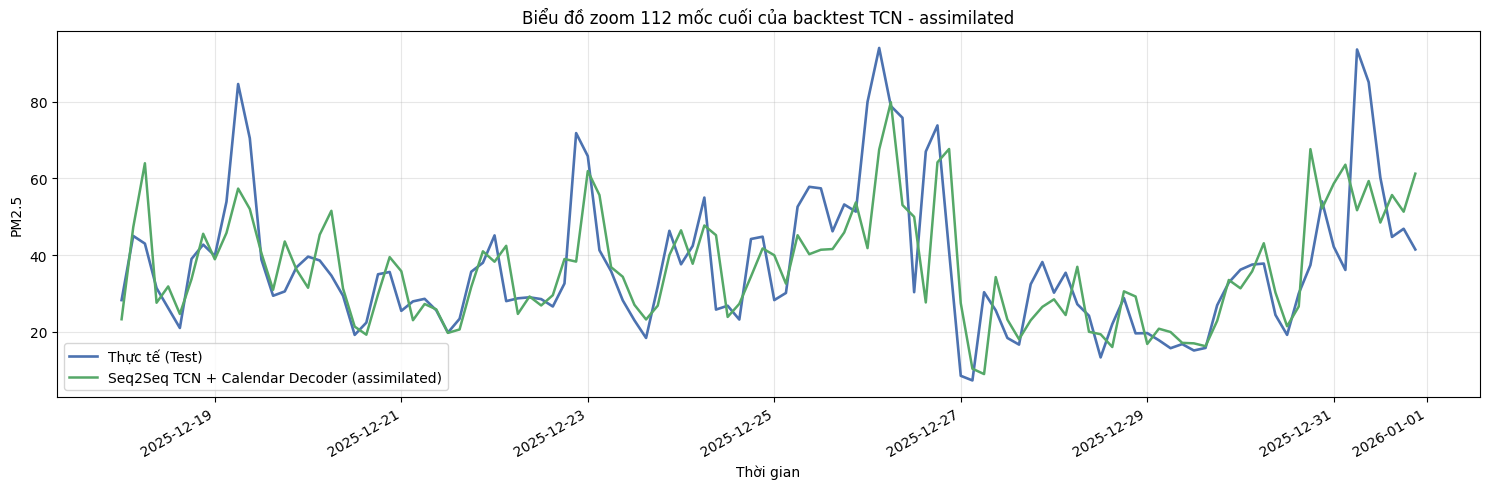

In [42]:
# ===== Seq2Seq TCN + Calendar Future Decoder walk-forward validation + full-test backtest =====

DECODER_FUTURE_COLS = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "IsHoliday",
]


def make_sequences_clean(X, y, lookback, horizon, decoder_future=None):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    if decoder_future is not None:
        decoder_future = np.asarray(decoder_future, dtype=np.float32)
        decoder_width = 1 + decoder_future.shape[1]
    else:
        decoder_width = 1

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, decoder_width), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]

        last_y = y[i + lookback - 1]
        decoder_seed = np.full((horizon, 1), last_y, dtype=np.float32)

        if decoder_future is not None:
            future_cov = decoder_future[i + lookback:i + lookback + horizon]
            decoder_input = np.concatenate([decoder_seed, future_cov], axis=1)
        else:
            decoder_input = decoder_seed

        decoder_seq.append(decoder_input)
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )


def prepare_train_eval_sequences_clean(
    train_X_df,
    train_y_df,
    eval_X_df,
    eval_y_df,
    lookback=72,
    horizon=72,
    target_mode="log1p",
    decoder_future_cols=None,
):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df phải có ít nhất `lookback` hàng")

    decoder_future_cols = [] if decoder_future_cols is None else list(decoder_future_cols)
    missing_decoder_cols = [c for c in decoder_future_cols if c not in train_X_df.columns]
    if missing_decoder_cols:
        raise ValueError(f"Thiếu decoder future cols: {missing_decoder_cols}")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    decoder_future_idx = [train_X_df.columns.get_loc(c) for c in decoder_future_cols]
    train_decoder_future = X_train_scaled[:, decoder_future_idx] if decoder_future_idx else None
    eval_decoder_future = X_eval_scaled[:, decoder_future_idx] if decoder_future_idx else None

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences_clean(
        X_train_scaled,
        y_train_scaled,
        lookback=lookback,
        horizon=horizon,
        decoder_future=train_decoder_future,
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])

    decoder_future_context = None
    if decoder_future_idx:
        decoder_future_context = np.vstack([
            train_decoder_future[-lookback:],
            eval_decoder_future,
        ])

    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences_clean(
        X_context,
        y_context,
        lookback=lookback,
        horizon=horizon,
        decoder_future=decoder_future_context,
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout, l2_reg=0.0, name="tcn_block"):
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    shortcut = x

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=f"{name}_conv1",
    )(x)
    y = tf.keras.layers.Dropout(dropout, name=f"{name}_drop1")(y)
    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=f"{name}_conv2",
    )(y)
    y = tf.keras.layers.Dropout(dropout, name=f"{name}_drop2")(y)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            kernel_regularizer=regularizer,
            name=f"{name}_proj",
        )(shortcut)

    added = tf.keras.layers.Add(name=f"{name}_add")([shortcut, y])
    return tf.keras.layers.Activation("relu", name=f"{name}_relu")(added)


def build_tcn_seq2seq_future_model(
    lookback,
    n_features,
    horizon,
    decoder_input_dim,
    encoder_filters=(64, 64, 128),
    decoder_filters=(64, 64),
    kernel_size=3,
    dilations=(1, 2, 4, 8),
    dense_units=128,
    dropout=0.15,
    learning_rate=7e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
):
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="tcn_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, decoder_input_dim), name="tcn_decoder_inputs")

    x_enc = encoder_inputs
    for block_idx, filters in enumerate(encoder_filters, start=1):
        for dilation in dilations:
            x_enc = tcn_residual_block(
                x_enc,
                filters=filters,
                kernel_size=kernel_size,
                dilation_rate=dilation,
                dropout=dropout,
                l2_reg=l2_reg,
                name=f"tcn_encoder_b{block_idx}_d{dilation}",
            )

    last_state = tf.keras.layers.Lambda(lambda z: z[:, -1, :], name="tcn_last_state")(x_enc)
    avg_state = tf.keras.layers.GlobalAveragePooling1D(name="tcn_avg_state")(x_enc)
    max_state = tf.keras.layers.GlobalMaxPooling1D(name="tcn_max_state")(x_enc)

    context = tf.keras.layers.Concatenate(name="tcn_context_concat")([last_state, avg_state, max_state])
    context = tf.keras.layers.Dense(
        decoder_filters[-1],
        activation="relu",
        kernel_regularizer=regularizer,
        name="tcn_context_dense",
    )(context)
    context = tf.keras.layers.RepeatVector(horizon, name="tcn_repeat_context")(context)

    x_dec = decoder_inputs
    for block_idx, filters in enumerate(decoder_filters, start=1):
        for dilation in dilations:
            x_dec = tcn_residual_block(
                x_dec,
                filters=filters,
                kernel_size=kernel_size,
                dilation_rate=dilation,
                dropout=dropout,
                l2_reg=l2_reg,
                name=f"tcn_decoder_b{block_idx}_d{dilation}",
            )

    x = tf.keras.layers.Concatenate(name="tcn_decoder_concat")([x_dec, context])

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="tcn_time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="tcn_decoder_dropout")(x)

    forecast_delta = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="tcn_time_distributed_output",
    )(x)
    forecast_delta = tf.keras.layers.Reshape((horizon,), name="tcn_forecast_delta")(forecast_delta)

    decoder_baseline = tf.keras.layers.Lambda(
        lambda z: tf.squeeze(z[:, :, :1], axis=-1),
        name="tcn_decoder_baseline",
    )(decoder_inputs)

    outputs = tf.keras.layers.Add(name="tcn_forecast_output")([forecast_delta, decoder_baseline])

    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="seq2seq_tcn_calendar_decoder",
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def build_decoder_future_frame(raw_df):
    frame = raw_df.copy().sort_index()

    frame["hour"] = frame.index.hour
    frame["dayofweek"] = frame.index.dayofweek
    frame["month"] = frame.index.month

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour"] / 24)
    frame["dow_sin"] = np.sin(2 * np.pi * frame["dayofweek"] / 7)
    frame["dow_cos"] = np.cos(2 * np.pi * frame["dayofweek"] / 7)
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)

    if "IsHoliday" in frame.columns:
        frame["IsHoliday"] = frame["IsHoliday"].astype(float)
    else:
        frame["IsHoliday"] = 0.0

    return frame


def scale_decoder_future_features(future_raw_df, feature_cols, x_scaler, decoder_future_cols):
    decoder_future_cols = list(decoder_future_cols)
    if not decoder_future_cols:
        return np.empty((len(future_raw_df), 0), dtype=np.float32)

    frame = build_decoder_future_frame(future_raw_df)
    missing_cols = [c for c in decoder_future_cols if c not in frame.columns]
    if missing_cols:
        raise ValueError(f"Thiếu decoder future cols trong future_raw_df: {missing_cols}")

    missing_from_feature_cols = [c for c in decoder_future_cols if c not in feature_cols]
    if missing_from_feature_cols:
        raise ValueError(f"Decoder future cols chưa nằm trong feature_cols: {missing_from_feature_cols}")

    idx = [feature_cols.index(c) for c in decoder_future_cols]
    values = frame[decoder_future_cols].to_numpy(dtype=np.float32)

    mean = np.asarray(x_scaler.mean_, dtype=np.float32)[idx]
    scale = np.asarray(x_scaler.scale_, dtype=np.float32)[idx]
    scale = np.where(np.isclose(scale, 0.0), 1.0, scale)

    return ((values - mean) / scale).astype(np.float32)


def make_tcn_decoder_input(
    chunk_future,
    feature_cols,
    x_scaler,
    last_target_scaled,
    chunk_horizon,
    decoder_future_cols,
):
    decoder_future = scale_decoder_future_features(
        chunk_future,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        decoder_future_cols=decoder_future_cols,
    )

    decoder_input = np.zeros((1, chunk_horizon, 1 + len(decoder_future_cols)), dtype=np.float32)
    decoder_input[0, :, 0] = float(last_target_scaled)

    effective_horizon = min(len(chunk_future), chunk_horizon)
    if len(decoder_future_cols) > 0 and effective_horizon > 0:
        decoder_input[0, :effective_horizon, 1:] = decoder_future[:effective_horizon]

    return decoder_input


def run_assimilated_rollout_tcn(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    decoder_rollout="constant_last",
    decoder_future_cols=None,
):
    if decoder_rollout not in ("autoregressive", "constant_last"):
        raise ValueError('decoder_rollout phải là "autoregressive" hoặc "constant_last".')

    decoder_future_cols = DECODER_FUTURE_COLS if decoder_future_cols is None else list(decoder_future_cols)

    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )

        decoder_input = make_tcn_decoder_input(
            chunk_future=chunk_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            last_target_scaled=last_target_scaled,
            chunk_horizon=chunk_horizon,
            decoder_future_cols=decoder_future_cols,
        )

        if decoder_rollout == "constant_last":
            y_pred_scaled = model.predict([X_input, decoder_input], verbose=0)[0][:effective_chunk_horizon].astype(np.float32)
        else:
            y_pred_scaled = np.zeros((chunk_horizon,), dtype=np.float32)
            decoder_input[0, :, 0] = float(last_target_scaled)
            for step_idx in range(effective_chunk_horizon):
                decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
                y_pred_scaled[step_idx] = decoder_forecast[step_idx]
                if step_idx + 1 < chunk_horizon:
                    decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(
            y_pred_scaled[:effective_chunk_horizon],
            y_scaler,
            mode=target_mode,
        )

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        history_raw_df = pd.concat([history_raw_df, chunk_future], axis=0)

    rollout_df = pd.DataFrame(rows)
    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def run_recursive_rollout_tcn(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    decoder_rollout="constant_last",
    decoder_future_cols=None,
):
    if decoder_rollout not in ("autoregressive", "constant_last"):
        raise ValueError('decoder_rollout phải là "autoregressive" hoặc "constant_last".')

    decoder_future_cols = DECODER_FUTURE_COLS if decoder_future_cols is None else list(decoder_future_cols)

    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )

        decoder_input = make_tcn_decoder_input(
            chunk_future=chunk_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            last_target_scaled=last_target_scaled,
            chunk_horizon=chunk_horizon,
            decoder_future_cols=decoder_future_cols,
        )

        if decoder_rollout == "constant_last":
            y_pred_scaled = model.predict([X_input, decoder_input], verbose=0)[0][:effective_chunk_horizon].astype(np.float32)
        else:
            y_pred_scaled = np.zeros((chunk_horizon,), dtype=np.float32)
            decoder_input[0, :, 0] = float(last_target_scaled)
            for step_idx in range(effective_chunk_horizon):
                decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
                y_pred_scaled[step_idx] = decoder_forecast[step_idx]
                if step_idx + 1 < chunk_horizon:
                    decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(
            y_pred_scaled[:effective_chunk_horizon],
            y_scaler,
            mode=target_mode,
        )

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        recursive_chunk = chunk_future.copy()
        recursive_chunk.loc[:, "PM25"] = np.asarray(y_pred, dtype=np.float64)
        history_raw_df = pd.concat([history_raw_df, recursive_chunk], axis=0)

    rollout_df = pd.DataFrame(rows)
    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def get_tcn_rollout_runner(policy):
    policy = str(policy).lower().strip()
    if policy == "assimilated":
        return run_assimilated_rollout_tcn
    if policy == "recursive":
        return run_recursive_rollout_tcn
    raise ValueError(f"Invalid ROLLING_POLICY: {policy}")


def run_backtest_over_full_test_tcn(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    rolling_policy="assimilated",
    decoder_rollout="constant_last",
    decoder_future_cols=None,
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index()
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rollout_runner = get_tcn_rollout_runner(rolling_policy)

    timeline_frames = []
    chunk_metric_frames = []
    window_rows = []
    global_chunk_id = 0

    for window_id, start in enumerate(range(0, len(future_raw_df), rollout_horizon), start=1):
        window_future = future_raw_df.iloc[start:start + rollout_horizon].copy()
        effective_horizon = len(window_future)
        if effective_horizon == 0:
            break

        window_summary = rollout_runner(
            model=model,
            history_raw_df=history_raw_df,
            future_raw_df=window_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            chunk_horizon=chunk_horizon,
            rollout_horizon=effective_horizon,
            target_mode=target_mode,
            decoder_rollout=decoder_rollout,
            decoder_future_cols=decoder_future_cols,
        )

        window_timeline_df = window_summary["timeline_df"].copy()
        window_timeline_df["window_id"] = window_id
        window_timeline_df["window_start"] = window_future.index.min()
        window_timeline_df["window_end"] = window_future.index.max()
        window_timeline_df["global_test_step"] = np.arange(start + 1, start + len(window_timeline_df) + 1)
        timeline_frames.append(window_timeline_df)

        window_metrics = window_summary["rollout_metrics"]
        window_rows.append({
            "window_id": window_id,
            "window_start": window_future.index.min(),
            "window_end": window_future.index.max(),
            "n_points": len(window_timeline_df),
            "mae": window_metrics["mae"],
            "rmse": window_metrics["rmse"],
            "mape": window_metrics["mape"],
            "peak_mae": window_metrics["peak_mae"],
            "peak_threshold": window_metrics["peak_threshold"],
        })

        window_chunk_metrics_df = window_summary["chunk_metrics_df"].copy()
        window_chunk_metrics_df = window_chunk_metrics_df.rename(columns={"chunk_id": "chunk_id_within_window"})
        window_chunk_metrics_df["window_id"] = window_id
        window_chunk_metrics_df["window_start"] = window_future.index.min()
        window_chunk_metrics_df["window_end"] = window_future.index.max()
        window_chunk_metrics_df["global_chunk_id"] = np.arange(
            global_chunk_id + 1,
            global_chunk_id + len(window_chunk_metrics_df) + 1,
        )
        global_chunk_id += len(window_chunk_metrics_df)
        chunk_metric_frames.append(window_chunk_metrics_df)

        history_raw_df = pd.concat([history_raw_df, window_future], axis=0)

    if not timeline_frames:
        raise ValueError("Không tạo được cửa sổ backtest nào.")

    timeline_df = pd.concat(timeline_frames, ignore_index=True)
    timeline_df = timeline_df.sort_values("timestamp").reset_index(drop=True)
    chunk_metrics_df = pd.concat(chunk_metric_frames, ignore_index=True) if chunk_metric_frames else pd.DataFrame()
    window_metrics_df = pd.DataFrame(window_rows)
    overall_metrics = compute_regression_metrics(
        timeline_df["y_true"].to_numpy(),
        timeline_df["y_pred"].to_numpy(),
        peak_quantile=PEAK_QUANTILE,
    )

    return {
        "timeline_df": timeline_df,
        "chunk_metrics_df": chunk_metrics_df,
        "window_metrics_df": window_metrics_df,
        "rollout_metrics": overall_metrics,
    }


TCN_MODEL_KWARGS = {
    "encoder_filters": (32, 64, 96),
    "decoder_filters": (32,),
    "kernel_size": 3,
    "dilations": (1, 2, 4),
    "dense_units": 64,
    "dropout": 0.10,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
}

TCN_MAX_FOLDS = min(MAX_FOLDS, 2)
TCN_SELECTOR_EPOCHS = min(EPOCHS, 30)
TCN_FINAL_EPOCH_CAP = min(EPOCHS, 36)
TCN_MODEL_LABEL = "Seq2Seq TCN + Calendar Decoder"

print("DECODER_FUTURE_COLS:", DECODER_FUTURE_COLS)
print("TCN_MODEL_KWARGS ready:", TCN_MODEL_KWARGS)
print("TCN_MODEL_LABEL:", TCN_MODEL_LABEL)
print("TCN_MAX_FOLDS / TCN_SELECTOR_EPOCHS / TCN_FINAL_EPOCH_CAP:", TCN_MAX_FOLDS, TCN_SELECTOR_EPOCHS, TCN_FINAL_EPOCH_CAP)


def fit_selector_model_tcn(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = TCN_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences_clean(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        decoder_future_cols=DECODER_FUTURE_COLS,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho TCN. Kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=float(PEAK_WEIGHT),
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_tcn_seq2seq_future_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        decoder_input_dim=decoder_train_seq.shape[2],
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_tcn(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = TCN_MODEL_KWARGS if model_kwargs is None else model_kwargs

    missing_decoder_cols = [c for c in DECODER_FUTURE_COLS if c not in full_X_df.columns]
    if missing_decoder_cols:
        raise ValueError(f"Thiếu decoder future cols: {missing_decoder_cols}")

    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)

    decoder_future_idx = [full_X_df.columns.get_loc(c) for c in DECODER_FUTURE_COLS]
    full_decoder_future = X_full_scaled[:, decoder_future_idx]

    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )

    X_full_seq, decoder_full_seq, y_full_seq = make_sequences_clean(
        X_full_scaled,
        y_full_scaled,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        decoder_future=full_decoder_future,
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho TCN.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=float(PEAK_WEIGHT),
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_tcn_seq2seq_future_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        decoder_input_dim=decoder_full_seq.shape[2],
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_tcn(
    feature_cols_local,
    history_feature_df,
    history_raw_df,
    future_raw_df,
    model_kwargs=None,
    selector_epochs=EPOCHS,
    rolling_policy=ROLLING_POLICY,
):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_tcn(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_epochs_local = resolve_final_epochs(best_epoch_local, multiplier=1.10, ceiling=TCN_FINAL_EPOCH_CAP)
    print(f"[TCN] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")

    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_tcn(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test_tcn(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        rolling_policy=rolling_policy,
        decoder_rollout="constant_last",
        decoder_future_cols=DECODER_FUTURE_COLS,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
        "decoder_future_cols": DECODER_FUTURE_COLS,
    }


tcn_rollout_runner = get_tcn_rollout_runner(ROLLING_POLICY)

tcn_fold_rows = []
tcn_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > TCN_MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    selector_model, history, best_epoch, _, _, peak_threshold_train = fit_selector_model_tcn(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=TCN_MODEL_KWARGS,
        epochs=TCN_SELECTOR_EPOCHS,
    )

    final_epochs = resolve_final_epochs(best_epoch, multiplier=1.10, ceiling=TCN_FINAL_EPOCH_CAP)
    final_model, x_scaler, y_scaler, peak_threshold_full = fit_full_history_model_tcn(
        fold_history_X,
        fold_history_y,
        epochs=final_epochs,
        model_kwargs=TCN_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = tcn_rollout_runner(
        model=final_model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        decoder_rollout="constant_last",
        decoder_future_cols=DECODER_FUTURE_COLS,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "best_epoch": best_epoch,
        "final_epochs": final_epochs,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        if chunk_id in chunk_metrics_df.index:
            chunk_metrics = chunk_metrics_df.loc[chunk_id]
            fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
            fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
            fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
            fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    tcn_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    tcn_fold_rows.append(fold_record)

tcn_walkforward_df = pd.DataFrame(tcn_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(tcn_walkforward_df)

if not tcn_walkforward_df.empty:
    summary_row = {
        "mean_rollout_mae": tcn_walkforward_df["rollout_mae"].mean(),
        "mean_rollout_rmse": tcn_walkforward_df["rollout_rmse"].mean(),
    }
    for chunk_id in range(1, N_CHUNKS + 1):
        col = f"chunk_{chunk_id}_mae"
        summary_row[f"mean_chunk_{chunk_id}_mae"] = (
            tcn_walkforward_df[col].mean() if col in tcn_walkforward_df.columns else np.nan
        )

    tcn_val_summary_df = pd.DataFrame([summary_row])
    print()
    print("=== Tổng kết validation của TCN ===")
    display(tcn_val_summary_df)

tcn_variant = fit_test_variant_tcn(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=TCN_MODEL_KWARGS,
    selector_epochs=TCN_SELECTOR_EPOCHS,
    rolling_policy=ROLLING_POLICY,
)

tcn_best_epoch_test = tcn_variant["best_epoch"]
tcn_peak_threshold_test_train = tcn_variant["train_peak_threshold_t"]
tcn_peak_threshold_test_full = tcn_variant["train_full_peak_threshold_t"]
tcn_test_eval_summary = tcn_variant["rollout_summary"]
tcn_test_timeline_df = tcn_test_eval_summary["timeline_df"].copy()
tcn_test_chunk_metrics_df = tcn_test_eval_summary["chunk_metrics_df"].copy()
tcn_test_window_metrics_df = tcn_test_eval_summary["window_metrics_df"].copy()
tcn_test_rollout_metrics = tcn_test_eval_summary["rollout_metrics"]

tcn_bundle_dir, tcn_bundle_zip = save_variant_bundle(
    variant=tcn_variant,
    model_name=TCN_MODEL_LABEL,
    metrics=tcn_test_rollout_metrics,
    bundle_key="seq2seq_tcn_calendar_decoder",
)

tcn_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": tcn_best_epoch_test,
        "test_rows": len(tcn_test_timeline_df),
        "n_backtest_windows": tcn_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": tcn_test_rollout_metrics["mae"],
        "test_rmse": tcn_test_rollout_metrics["rmse"],
        "test_mape": tcn_test_rollout_metrics["mape"],
        "test_peak_mae": tcn_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": tcn_peak_threshold_test_train,
        "train_val_peak_threshold_t": tcn_peak_threshold_test_full,
    }
])

tcn_test_report_df = pd.DataFrame([
    {
        "model": TCN_MODEL_LABEL,
        "test_rows": len(tcn_test_timeline_df),
        "n_backtest_windows": tcn_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": tcn_test_rollout_metrics["mae"],
        "rmse": tcn_test_rollout_metrics["rmse"],
        "mape": tcn_test_rollout_metrics["mape"],
        "best_epoch": tcn_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest TCN trên toàn bộ tập test ===")
display(tcn_test_metrics_df)
print()
print("=== Chỉ số TCN theo từng cửa sổ backtest ===")
display(tcn_test_window_metrics_df)
print()
print("=== Chỉ số TCN theo từng chunk trong backtest ===")
display(tcn_test_chunk_metrics_df)
print()
print("=== Bảng tóm tắt kết quả của TCN ===")
display(tcn_test_report_df)

tcn_zoom_n = min(len(tcn_test_timeline_df), int(14 * 24 / STEP_HOURS))
tcn_zoom_df = tcn_test_timeline_df.tail(tcn_zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(tcn_zoom_df["timestamp"], tcn_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(tcn_zoom_df["timestamp"], tcn_zoom_df["y_pred"], label=f"{TCN_MODEL_LABEL} ({ROLLING_POLICY})", linewidth=1.8, color="#55A868")
plt.title(f"Biểu đồ zoom {tcn_zoom_n} mốc cuối của backtest TCN - {ROLLING_POLICY}")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


## 16. Encoder-only Transformer


TRANSFORMER_MODEL_KWARGS sẵn sàng: {'d_model': 64, 'num_heads': 4, 'ff_dim': 128, 'num_blocks': 2, 'dense_units': 64, 'decoder_dense_units': 32, 'dropout': 0.15, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0}
TRANSFORMER_MODEL_LABEL: Direct Transformer

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 38: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 46: ReduceLROnPlateau reducing learning rate to 4.374999844003469e-05.

Epoch 54: ReduceLROnPlateau reducing learning rate to 2.1874999220017344e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 34: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 26: ReduceLROnPlateau r

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,8.662024,11.254952,29.032611,20.662351,54.667333,1.272260,...,23.661394,8.675844,14.117032,14.117032,130.311066,14.117032,0.519135,0.519135,4.866889,0.519135
1,2,8004,56,24,5.926479,8.461071,31.823828,5.553510,24.934000,1.270774,...,34.218216,5.760066,0.122345,0.122345,0.692519,0.122345,6.153330,6.153330,36.554435,6.153330
2,3,8028,56,24,8.860772,11.637322,25.434472,16.940152,75.279167,1.269296,...,10.449108,5.441895,24.803062,24.803062,162.040909,24.803062,2.681857,2.681857,19.748580,2.681857
3,4,8052,56,24,7.021806,8.646855,20.901433,9.720350,48.290667,1.268924,...,34.646471,13.823942,2.670647,2.670647,9.585954,2.670647,1.310579,1.310579,5.594389,1.310579



=== Tổng kết validation của Transformer ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,7.61777,10.00005,4.132325,8.265918,14.73532



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 29: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
[Transformer] selector best_epoch=5, final_epochs=10
Saved bundle for Direct Transformer: /content/model_registry/direct_transformer

=== Kết quả test Transformer ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.570309,4.769102,26.384811,3.186676,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,6.685749,11.275376,37.596421,19.122807,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,3.532862,5.159365,17.515144,6.273440,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,8.068181,12.943646,33.071596,24.690891,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,6.600269,13.972906,23.776014,31.113869,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,6.292618,8.841273,17.903074,13.018621,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,8.440771,12.348559,24.861130,17.402633,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,13.289878,17.236489,47.056157,11.507657,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,4.759132,6.234396,18.936851,9.578686,37.720000



=== Chỉ số Transformer theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,1.985922,1.985922,7.605010,1.985922,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,3.782322,3.782322,15.065012,3.782322,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,11.137145,11.137145,75.352811,11.137145,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,4.146285,4.146285,20.962007,4.146285,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,0.071064,0.071064,0.325482,0.071064,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,5.547843,5.547843,6.521759,5.547843,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,5.554394,5.554394,9.226568,5.554394,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,1.333761,1.333761,2.981582,1.333761,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,1.148542,1.148542,2.450660,1.148542,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tổng hợp kết quả của Transformer ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,mape,best_epoch
0,Direct Transformer,1735,73,24,1,5.934257,10.311164,25.617006,5


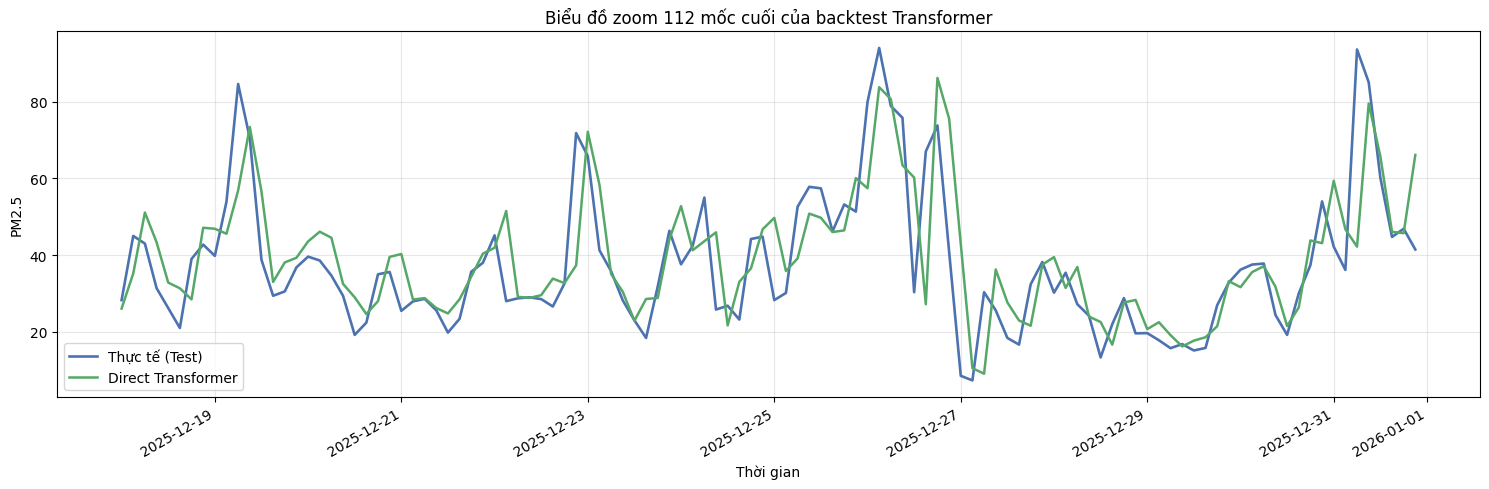

In [44]:
def build_transformer_direct_model(
    lookback,
    n_features,
    horizon,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_blocks=2,
    dense_units=64,
    decoder_dense_units=32,  # giữ lại để không lỗi kwargs cũ, nhưng không dùng
    dropout=0.15,
    learning_rate=7e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
):
    if d_model % num_heads != 0:
        raise ValueError("d_model phải chia hết cho num_heads để đảm bảo head_dim là một số nguyên.")

    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    head_dim = max(d_model // num_heads, 1)

    encoder_inputs = tf.keras.layers.Input(
        shape=(lookback, n_features),
        name="transformer_encoder_inputs",
    )

    # Giữ decoder_inputs để tương thích với pipeline cũ:
    # model.fit([X_seq, decoder_seq], y_seq)
    decoder_inputs = tf.keras.layers.Input(
        shape=(horizon, 1),
        name="transformer_decoder_inputs",
    )

    x = tf.keras.layers.Dense(
        d_model,
        kernel_regularizer=regularizer,
        name="transformer_input_projection",
    )(encoder_inputs)

    position_indices = tf.keras.layers.Lambda(lambda z: tf.tile(
        tf.range(tf.shape(z)[1], dtype=tf.int32)[tf.newaxis, :],
        [tf.shape(z)[0], 1],
    ), name="transformer_position_indices",)(encoder_inputs)


    position_embeddings = tf.keras.layers.Embedding(input_dim=lookback, output_dim=d_model, name="transformer_position_embedding",)(position_indices)
    x = tf.keras.layers.Add(name="transformer_add_position")([x, position_embeddings])
    x = tf.keras.layers.Dropout(dropout, name="transformer_input_dropout")(x)

    for block_idx in range(1, num_blocks + 1):
        attn_input = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_ln_attn_{block_idx}",
        )(x)

        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=head_dim,
            dropout=dropout,
            kernel_regularizer=regularizer,
            name=f"transformer_mha_{block_idx}",
        )(attn_input, attn_input)

        attn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_attn_dropout_{block_idx}",
        )(attn_output)

        x = tf.keras.layers.Add(name=f"transformer_attn_residual_{block_idx}")(
            [x, attn_output]
        )

        ffn_input = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_ln_ffn_{block_idx}",
        )(x)

        ffn_output = tf.keras.layers.Dense(
            ff_dim,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"transformer_ffn_expand_{block_idx}",
        )(ffn_input)

        ffn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_ffn_expand_dropout_{block_idx}",
        )(ffn_output)

        ffn_output = tf.keras.layers.Dense(
            d_model,
            kernel_regularizer=regularizer,
            name=f"transformer_ffn_project_{block_idx}",
        )(ffn_output)

        ffn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_ffn_project_dropout_{block_idx}",
        )(ffn_output)

        x = tf.keras.layers.Add(name=f"transformer_ffn_residual_{block_idx}")(
            [x, ffn_output]
        )

    x = tf.keras.layers.LayerNormalization(
        epsilon=1e-6,
        name="transformer_encoder_output_norm",
    )(x)

    last_context = tf.keras.layers.Lambda(
        lambda z: z[:, -1, :],
        name="transformer_last_context",
    )(x)

    avg_context = tf.keras.layers.GlobalAveragePooling1D(
        name="transformer_avg_pool",
    )(x)

    max_context = tf.keras.layers.GlobalMaxPooling1D(
        name="transformer_max_pool",
    )(x)

    x = tf.keras.layers.Concatenate(name="transformer_context_concat")(
        [last_context, avg_context, max_context]
    )

    if dense_units:
        x = tf.keras.layers.Dense(
            dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name="transformer_head_dense",
        )(x)

        x = tf.keras.layers.Dropout(
            dropout,
            name="transformer_head_dropout",
        )(x)

    forecast_delta = tf.keras.layers.Dense(
        horizon,
        kernel_regularizer=regularizer,
        name="transformer_forecast_delta",
    )(x)

    decoder_baseline = tf.keras.layers.Reshape(
        (horizon,),
        name="transformer_decoder_baseline",
    )(decoder_inputs)

    outputs = tf.keras.layers.Add(name="transformer_forecast_output")(
        [forecast_delta, decoder_baseline]
    )

    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="direct_transformer",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=clipnorm,
        ),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )

    return model




TRANSFORMER_MODEL_KWARGS = {
    "d_model": 64,
    "num_heads": 4,
    "ff_dim": 128,
    "num_blocks": 2,
    "dense_units": 64,
    "decoder_dense_units": 32,
    "dropout": 0.15,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
}
TRANSFORMER_MODEL_LABEL = "Direct Transformer"
print("TRANSFORMER_MODEL_KWARGS sẵn sàng:", TRANSFORMER_MODEL_KWARGS)
print("TRANSFORMER_MODEL_LABEL:", TRANSFORMER_MODEL_LABEL)


def fit_selector_model_transformer(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = TRANSFORMER_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences_clean(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho Transformer.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_transformer_direct_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_transformer(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = TRANSFORMER_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences_clean(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho Transformer.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_transformer_direct_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold



def fit_test_variant_transformer(
    feature_cols_local,
    history_feature_df,
    history_raw_df,
    future_raw_df,
    model_kwargs=None,
    selector_epochs=EPOCHS,
    rolling_policy=ROLLING_POLICY,
):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )

    final_epochs_local = resolve_final_epochs(best_epoch_local)
    print(f"[Transformer] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")

    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_transformer(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )

    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        rolling_policy=rolling_policy,
        decoder_rollout="constant_last",
    )

    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
    }


transformer_fold_rows = []
transformer_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=TRANSFORMER_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        decoder_rollout="constant_last",
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    transformer_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    transformer_fold_rows.append(fold_record)

transformer_walkforward_df = pd.DataFrame(transformer_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(transformer_walkforward_df)

if not transformer_walkforward_df.empty:
    transformer_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": transformer_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": transformer_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": transformer_walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": transformer_walkforward_df["chunk_2_mae"].mean() if "chunk_2_mae" in transformer_walkforward_df.columns else np.nan,
            "mean_chunk_3_mae": transformer_walkforward_df["chunk_3_mae"].mean() if "chunk_3_mae" in transformer_walkforward_df.columns else np.nan,
        }
    ])
    print()
    print("=== Tổng kết validation của Transformer ===")
    display(transformer_val_summary_df)

transformer_variant = fit_test_variant_transformer(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=TRANSFORMER_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

transformer_best_epoch_test = transformer_variant["best_epoch"]
transformer_peak_threshold_test_train = transformer_variant["train_peak_threshold_t"]
transformer_peak_threshold_test_full = transformer_variant["train_full_peak_threshold_t"]
transformer_test_eval_summary = transformer_variant["rollout_summary"]
transformer_test_timeline_df = transformer_test_eval_summary["timeline_df"].copy()
transformer_test_chunk_metrics_df = transformer_test_eval_summary["chunk_metrics_df"].copy()
transformer_test_window_metrics_df = transformer_test_eval_summary["window_metrics_df"].copy()
transformer_test_rollout_metrics = transformer_test_eval_summary["rollout_metrics"]
transformer_bundle_dir, transformer_bundle_zip = save_variant_bundle(
    variant=transformer_variant,
    model_name=TRANSFORMER_MODEL_LABEL,
    metrics=transformer_test_rollout_metrics,
    bundle_key="direct_transformer",
)

transformer_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": transformer_best_epoch_test,
        "test_rows": len(transformer_test_timeline_df),
        "n_backtest_windows": transformer_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": transformer_test_rollout_metrics["mae"],
        "test_rmse": transformer_test_rollout_metrics["rmse"],
        "test_mape": transformer_test_rollout_metrics["mape"],
        "test_peak_mae": transformer_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": transformer_peak_threshold_test_train,
        "train_val_peak_threshold_t": transformer_peak_threshold_test_full,
    }
])

transformer_test_report_df = pd.DataFrame([
    {
        "model": TRANSFORMER_MODEL_LABEL,
        "test_rows": len(transformer_test_timeline_df),
        "n_backtest_windows": transformer_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": transformer_test_rollout_metrics["mae"],
        "rmse": transformer_test_rollout_metrics["rmse"],
        "mape": transformer_test_rollout_metrics["mape"],
        "best_epoch": transformer_best_epoch_test,
    }
])

print()
print("=== Kết quả test Transformer ===")
display(transformer_test_metrics_df)
print()
print("=== Chỉ số Transformer theo từng cửa sổ backtest ===")
display(transformer_test_window_metrics_df)
print()
print("=== Chỉ số Transformer theo từng chunk trong backtest ===")
display(transformer_test_chunk_metrics_df)
print()
print("=== Bảng tổng hợp kết quả của Transformer ===")
display(transformer_test_report_df)



transformer_zoom_n = min(len(transformer_test_timeline_df), int(14 * 24 / STEP_HOURS))
transformer_zoom_df = transformer_test_timeline_df.tail(transformer_zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(transformer_zoom_df["timestamp"], transformer_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(transformer_zoom_df["timestamp"], transformer_zoom_df["y_pred"], label=TRANSFORMER_MODEL_LABEL, linewidth=1.8, color="#55A868")
plt.title(f"Biểu đồ zoom {transformer_zoom_n} mốc cuối của backtest Transformer")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
# ===== Direct Transformer + Calendar Decoder walk-forward validation + full-test backtest =====

TRANSFORMER_DECODER_FUTURE_COLS = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "IsHoliday",
]


def make_sequences_transformer(X, y, lookback, horizon, decoder_future=None):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    if decoder_future is not None:
        decoder_future = np.asarray(decoder_future, dtype=np.float32)
        decoder_width = 1 + decoder_future.shape[1]
    else:
        decoder_width = 1

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, decoder_width), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]

        last_y = y[i + lookback - 1]
        decoder_seed = np.full((horizon, 1), last_y, dtype=np.float32)

        if decoder_future is not None:
            future_cov = decoder_future[i + lookback:i + lookback + horizon]
            decoder_input = np.concatenate([decoder_seed, future_cov], axis=1)
        else:
            decoder_input = decoder_seed

        decoder_seq.append(decoder_input)
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )


def prepare_train_eval_sequences_transformer(
    train_X_df,
    train_y_df,
    eval_X_df,
    eval_y_df,
    lookback=72,
    horizon=72,
    target_mode="log1p",
    decoder_future_cols=None,
):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df phải có ít nhất `lookback` hàng")

    decoder_future_cols = [] if decoder_future_cols is None else list(decoder_future_cols)
    missing_decoder_cols = [c for c in decoder_future_cols if c not in train_X_df.columns]
    if missing_decoder_cols:
        raise ValueError(f"Thiếu decoder future cols: {missing_decoder_cols}")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    decoder_future_idx = [train_X_df.columns.get_loc(c) for c in decoder_future_cols]
    train_decoder_future = X_train_scaled[:, decoder_future_idx] if decoder_future_idx else None
    eval_decoder_future = X_eval_scaled[:, decoder_future_idx] if decoder_future_idx else None

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences_transformer(
        X_train_scaled,
        y_train_scaled,
        lookback=lookback,
        horizon=horizon,
        decoder_future=train_decoder_future,
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])

    decoder_future_context = None
    if decoder_future_idx:
        decoder_future_context = np.vstack([
            train_decoder_future[-lookback:],
            eval_decoder_future,
        ])

    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences_transformer(
        X_context,
        y_context,
        lookback=lookback,
        horizon=horizon,
        decoder_future=decoder_future_context,
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def build_transformer_direct_model(
    lookback,
    n_features,
    horizon,
    decoder_input_dim=1,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_blocks=2,
    dense_units=64,
    decoder_dense_units=32,
    dropout=0.15,
    learning_rate=7e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
):
    if d_model % num_heads != 0:
        raise ValueError("d_model phải chia hết cho num_heads.")

    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    head_dim = max(d_model // num_heads, 1)

    encoder_inputs = tf.keras.layers.Input(
        shape=(lookback, n_features),
        name="transformer_encoder_inputs",
    )
    decoder_inputs = tf.keras.layers.Input(
        shape=(horizon, decoder_input_dim),
        name="transformer_decoder_inputs",
    )

    x = tf.keras.layers.Dense(
        d_model,
        kernel_regularizer=regularizer,
        name="transformer_input_projection",
    )(encoder_inputs)

    position_indices = tf.keras.layers.Lambda(
        lambda z: tf.tile(
            tf.range(tf.shape(z)[1], dtype=tf.int32)[tf.newaxis, :],
            [tf.shape(z)[0], 1],
        ),
        name="transformer_position_indices",
    )(encoder_inputs)

    position_embeddings = tf.keras.layers.Embedding(
        input_dim=lookback,
        output_dim=d_model,
        name="transformer_position_embedding",
    )(position_indices)

    x = tf.keras.layers.Add(name="transformer_add_position")([x, position_embeddings])
    x = tf.keras.layers.Dropout(dropout, name="transformer_input_dropout")(x)

    for block_idx in range(1, num_blocks + 1):
        attn_input = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_ln_attn_{block_idx}",
        )(x)
        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=head_dim,
            dropout=dropout,
            kernel_regularizer=regularizer,
            name=f"transformer_mha_{block_idx}",
        )(attn_input, attn_input)
        attn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_attn_dropout_{block_idx}",
        )(attn_output)
        x = tf.keras.layers.Add(name=f"transformer_attn_residual_{block_idx}")([x, attn_output])

        ffn_input = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_ln_ffn_{block_idx}",
        )(x)
        ffn_output = tf.keras.layers.Dense(
            ff_dim,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"transformer_ffn_expand_{block_idx}",
        )(ffn_input)
        ffn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_ffn_expand_dropout_{block_idx}",
        )(ffn_output)
        ffn_output = tf.keras.layers.Dense(
            d_model,
            kernel_regularizer=regularizer,
            name=f"transformer_ffn_project_{block_idx}",
        )(ffn_output)
        ffn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_ffn_project_dropout_{block_idx}",
        )(ffn_output)
        x = tf.keras.layers.Add(name=f"transformer_ffn_residual_{block_idx}")([x, ffn_output])

    x = tf.keras.layers.LayerNormalization(
        epsilon=1e-6,
        name="transformer_encoder_output_norm",
    )(x)

    last_context = tf.keras.layers.Lambda(lambda z: z[:, -1, :], name="transformer_last_context")(x)
    avg_context = tf.keras.layers.GlobalAveragePooling1D(name="transformer_avg_pool")(x)
    max_context = tf.keras.layers.GlobalMaxPooling1D(name="transformer_max_pool")(x)

    contexts = [last_context, avg_context, max_context]

    if decoder_input_dim > 1:
        future_context = tf.keras.layers.Lambda(
            lambda z: z[:, :, 1:],
            name="transformer_decoder_future_slice",
        )(decoder_inputs)
        future_context = tf.keras.layers.Flatten(name="transformer_decoder_future_flatten")(future_context)

        if decoder_dense_units:
            future_context = tf.keras.layers.Dense(
                decoder_dense_units,
                activation="relu",
                kernel_regularizer=regularizer,
                name="transformer_decoder_future_dense",
            )(future_context)
            future_context = tf.keras.layers.Dropout(
                dropout,
                name="transformer_decoder_future_dropout",
            )(future_context)

        contexts.append(future_context)

    x = tf.keras.layers.Concatenate(name="transformer_context_concat")(contexts)

    if dense_units:
        x = tf.keras.layers.Dense(
            dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name="transformer_head_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="transformer_head_dropout")(x)

    forecast_delta = tf.keras.layers.Dense(
        horizon,
        kernel_regularizer=regularizer,
        name="transformer_forecast_delta",
    )(x)

    decoder_baseline = tf.keras.layers.Lambda(
        lambda z: tf.squeeze(z[:, :, :1], axis=-1),
        name="transformer_decoder_baseline",
    )(decoder_inputs)

    outputs = tf.keras.layers.Add(name="transformer_forecast_output")(
        [forecast_delta, decoder_baseline]
    )

    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="direct_transformer_calendar_decoder",
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def build_transformer_decoder_future_frame(raw_df):
    frame = raw_df.copy().sort_index()

    frame["hour"] = frame.index.hour
    frame["dayofweek"] = frame.index.dayofweek
    frame["month"] = frame.index.month

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour"] / 24)
    frame["dow_sin"] = np.sin(2 * np.pi * frame["dayofweek"] / 7)
    frame["dow_cos"] = np.cos(2 * np.pi * frame["dayofweek"] / 7)
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)

    if "IsHoliday" in frame.columns:
        frame["IsHoliday"] = frame["IsHoliday"].astype(float)
    else:
        frame["IsHoliday"] = 0.0

    return frame


def scale_transformer_decoder_future_features(future_raw_df, feature_cols, x_scaler, decoder_future_cols):
    decoder_future_cols = list(decoder_future_cols)
    if not decoder_future_cols:
        return np.empty((len(future_raw_df), 0), dtype=np.float32)

    frame = build_transformer_decoder_future_frame(future_raw_df)

    missing_cols = [c for c in decoder_future_cols if c not in frame.columns]
    if missing_cols:
        raise ValueError(f"Thiếu decoder future cols trong future_raw_df: {missing_cols}")

    missing_from_feature_cols = [c for c in decoder_future_cols if c not in feature_cols]
    if missing_from_feature_cols:
        raise ValueError(f"Decoder future cols chưa nằm trong feature_cols: {missing_from_feature_cols}")

    idx = [feature_cols.index(c) for c in decoder_future_cols]
    values = frame[decoder_future_cols].to_numpy(dtype=np.float32)

    mean = np.asarray(x_scaler.mean_, dtype=np.float32)[idx]
    scale = np.asarray(x_scaler.scale_, dtype=np.float32)[idx]
    scale = np.where(np.isclose(scale, 0.0), 1.0, scale)

    return ((values - mean) / scale).astype(np.float32)


def make_transformer_decoder_input(
    chunk_future,
    feature_cols,
    x_scaler,
    last_target_scaled,
    chunk_horizon,
    decoder_future_cols,
):
    decoder_future_cols = list(decoder_future_cols)
    decoder_future = scale_transformer_decoder_future_features(
        chunk_future,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        decoder_future_cols=decoder_future_cols,
    )

    decoder_input = np.zeros((1, chunk_horizon, 1 + len(decoder_future_cols)), dtype=np.float32)
    decoder_input[0, :, 0] = float(last_target_scaled)

    effective_horizon = min(len(chunk_future), chunk_horizon)
    if len(decoder_future_cols) > 0 and effective_horizon > 0:
        decoder_input[0, :effective_horizon, 1:] = decoder_future[:effective_horizon]

    return decoder_input


def run_assimilated_rollout_transformer(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    decoder_rollout="constant_last",
    decoder_future_cols=None,
):
    decoder_future_cols = TRANSFORMER_DECODER_FUTURE_COLS if decoder_future_cols is None else list(decoder_future_cols)

    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )

        decoder_input = make_transformer_decoder_input(
            chunk_future=chunk_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            last_target_scaled=last_target_scaled,
            chunk_horizon=chunk_horizon,
            decoder_future_cols=decoder_future_cols,
        )

        y_pred_scaled = model.predict([X_input, decoder_input], verbose=0)[0][:effective_chunk_horizon].astype(np.float32)

        y_pred = inverse_target(
            y_pred_scaled,
            y_scaler,
            mode=target_mode,
        )

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        history_raw_df = pd.concat([history_raw_df, chunk_future], axis=0)

    rollout_df = pd.DataFrame(rows)
    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def run_recursive_rollout_transformer(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    decoder_rollout="constant_last",
    decoder_future_cols=None,
):
    decoder_future_cols = TRANSFORMER_DECODER_FUTURE_COLS if decoder_future_cols is None else list(decoder_future_cols)

    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )

        decoder_input = make_transformer_decoder_input(
            chunk_future=chunk_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            last_target_scaled=last_target_scaled,
            chunk_horizon=chunk_horizon,
            decoder_future_cols=decoder_future_cols,
        )

        y_pred_scaled = model.predict([X_input, decoder_input], verbose=0)[0][:effective_chunk_horizon].astype(np.float32)

        y_pred = inverse_target(
            y_pred_scaled,
            y_scaler,
            mode=target_mode,
        )

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        recursive_chunk = chunk_future.copy()
        recursive_chunk.loc[:, "PM25"] = np.asarray(y_pred, dtype=np.float64)
        history_raw_df = pd.concat([history_raw_df, recursive_chunk], axis=0)

    rollout_df = pd.DataFrame(rows)
    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def get_transformer_rollout_runner(policy):
    policy = str(policy).lower().strip()
    if policy == "assimilated":
        return run_assimilated_rollout_transformer
    if policy == "recursive":
        return run_recursive_rollout_transformer
    raise ValueError(f"Invalid ROLLING_POLICY: {policy}")


def run_backtest_over_full_test_transformer(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
    rolling_policy="assimilated",
    decoder_rollout="constant_last",
    decoder_future_cols=None,
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index()
    if len(future_raw_df) == 0:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rollout_runner = get_transformer_rollout_runner(rolling_policy)

    timeline_frames = []
    chunk_metric_frames = []
    window_rows = []
    global_chunk_id = 0

    for window_id, start in enumerate(range(0, len(future_raw_df), rollout_horizon), start=1):
        window_future = future_raw_df.iloc[start:start + rollout_horizon].copy()
        effective_horizon = len(window_future)
        if effective_horizon == 0:
            break

        window_summary = rollout_runner(
            model=model,
            history_raw_df=history_raw_df,
            future_raw_df=window_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            chunk_horizon=chunk_horizon,
            rollout_horizon=effective_horizon,
            target_mode=target_mode,
            decoder_rollout=decoder_rollout,
            decoder_future_cols=decoder_future_cols,
        )

        window_timeline_df = window_summary["timeline_df"].copy()
        window_timeline_df["window_id"] = window_id
        window_timeline_df["window_start"] = window_future.index.min()
        window_timeline_df["window_end"] = window_future.index.max()
        window_timeline_df["global_test_step"] = np.arange(start + 1, start + len(window_timeline_df) + 1)
        timeline_frames.append(window_timeline_df)

        window_metrics = window_summary["rollout_metrics"]
        window_rows.append({
            "window_id": window_id,
            "window_start": window_future.index.min(),
            "window_end": window_future.index.max(),
            "n_points": len(window_timeline_df),
            "mae": window_metrics["mae"],
            "rmse": window_metrics["rmse"],
            "mape": window_metrics["mape"],
            "peak_mae": window_metrics["peak_mae"],
            "peak_threshold": window_metrics["peak_threshold"],
        })

        window_chunk_metrics_df = window_summary["chunk_metrics_df"].copy()
        window_chunk_metrics_df = window_chunk_metrics_df.rename(columns={"chunk_id": "chunk_id_within_window"})
        window_chunk_metrics_df["window_id"] = window_id
        window_chunk_metrics_df["window_start"] = window_future.index.min()
        window_chunk_metrics_df["window_end"] = window_future.index.max()
        window_chunk_metrics_df["global_chunk_id"] = np.arange(
            global_chunk_id + 1,
            global_chunk_id + len(window_chunk_metrics_df) + 1,
        )
        global_chunk_id += len(window_chunk_metrics_df)
        chunk_metric_frames.append(window_chunk_metrics_df)

        history_raw_df = pd.concat([history_raw_df, window_future], axis=0)

    if not timeline_frames:
        raise ValueError("Không tạo được cửa sổ backtest nào.")

    timeline_df = pd.concat(timeline_frames, ignore_index=True)
    timeline_df = timeline_df.sort_values("timestamp").reset_index(drop=True)
    chunk_metrics_df = pd.concat(chunk_metric_frames, ignore_index=True) if chunk_metric_frames else pd.DataFrame()
    window_metrics_df = pd.DataFrame(window_rows)
    overall_metrics = compute_regression_metrics(
        timeline_df["y_true"].to_numpy(),
        timeline_df["y_pred"].to_numpy(),
        peak_quantile=PEAK_QUANTILE,
    )

    return {
        "timeline_df": timeline_df,
        "chunk_metrics_df": chunk_metrics_df,
        "window_metrics_df": window_metrics_df,
        "rollout_metrics": overall_metrics,
    }


TRANSFORMER_MODEL_KWARGS = {
    "d_model": 64,
    "num_heads": 4,
    "ff_dim": 128,
    "num_blocks": 2,
    "dense_units": 64,
    "decoder_dense_units": 32,
    "dropout": 0.15,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
}
TRANSFORMER_MODEL_LABEL = "Direct Transformer + Calendar Decoder"
print("TRANSFORMER_DECODER_FUTURE_COLS:", TRANSFORMER_DECODER_FUTURE_COLS)
print("TRANSFORMER_MODEL_KWARGS sẵn sàng:", TRANSFORMER_MODEL_KWARGS)
print("TRANSFORMER_MODEL_LABEL:", TRANSFORMER_MODEL_LABEL)


def fit_selector_model_transformer(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = TRANSFORMER_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        decoder_future_cols=TRANSFORMER_DECODER_FUTURE_COLS,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho Transformer.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    tf.keras.backend.clear_session()

    model = build_transformer_direct_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        decoder_input_dim=decoder_train_seq.shape[2],
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_transformer(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = TRANSFORMER_MODEL_KWARGS if model_kwargs is None else model_kwargs

    missing_decoder_cols = [c for c in TRANSFORMER_DECODER_FUTURE_COLS if c not in full_X_df.columns]
    if missing_decoder_cols:
        raise ValueError(f"Thiếu decoder future cols: {missing_decoder_cols}")

    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)

    decoder_future_idx = [full_X_df.columns.get_loc(c) for c in TRANSFORMER_DECODER_FUTURE_COLS]
    full_decoder_future = X_full_scaled[:, decoder_future_idx]

    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )

    X_full_seq, decoder_full_seq, y_full_seq = make_sequences_transformer(
        X_full_scaled,
        y_full_scaled,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        decoder_future=full_decoder_future,
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho Transformer.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    tf.keras.backend.clear_session()

    model = build_transformer_direct_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        decoder_input_dim=decoder_full_seq.shape[2],
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_transformer(
    feature_cols_local,
    history_feature_df,
    history_raw_df,
    future_raw_df,
    model_kwargs=None,
    selector_epochs=EPOCHS,
    rolling_policy=ROLLING_POLICY,
):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )

    final_epochs_local = resolve_final_epochs(best_epoch_local)
    print(f"[Transformer] selector best_epoch={best_epoch_local}, final_epochs={final_epochs_local}")

    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_transformer(
        history_X_df,
        history_y_df,
        final_epochs_local,
        model_kwargs=model_kwargs,
    )

    rollout_summary = run_backtest_over_full_test_transformer(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        rolling_policy=rolling_policy,
        decoder_rollout="constant_last",
        decoder_future_cols=TRANSFORMER_DECODER_FUTURE_COLS,
    )

    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "final_epochs": final_epochs_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
        "final_model": final_model,
        "x_scaler": x_scaler_local,
        "y_scaler": y_scaler_local,
        "feature_cols": feature_cols_local,
        "decoder_future_cols": TRANSFORMER_DECODER_FUTURE_COLS,
    }


transformer_fold_rows = []
transformer_compare_samples = []
transformer_rollout_runner = get_transformer_rollout_runner(ROLLING_POLICY)

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=TRANSFORMER_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = transformer_rollout_runner(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
        decoder_rollout="constant_last",
        decoder_future_cols=TRANSFORMER_DECODER_FUTURE_COLS,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        if chunk_id in chunk_metrics_df.index:
            chunk_metrics = chunk_metrics_df.loc[chunk_id]
            fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
            fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
            fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
            fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    transformer_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    transformer_fold_rows.append(fold_record)

transformer_walkforward_df = pd.DataFrame(transformer_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(transformer_walkforward_df)

if not transformer_walkforward_df.empty:
    transformer_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": transformer_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": transformer_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": transformer_walkforward_df["chunk_1_mae"].mean() if "chunk_1_mae" in transformer_walkforward_df.columns else np.nan,
            "mean_chunk_2_mae": transformer_walkforward_df["chunk_2_mae"].mean() if "chunk_2_mae" in transformer_walkforward_df.columns else np.nan,
            "mean_chunk_3_mae": transformer_walkforward_df["chunk_3_mae"].mean() if "chunk_3_mae" in transformer_walkforward_df.columns else np.nan,
        }
    ])
    print()
    print("=== Tổng kết validation của Transformer ===")
    display(transformer_val_summary_df)

transformer_variant = fit_test_variant_transformer(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=TRANSFORMER_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

transformer_best_epoch_test = transformer_variant["best_epoch"]
transformer_peak_threshold_test_train = transformer_variant["train_peak_threshold_t"]
transformer_peak_threshold_test_full = transformer_variant["train_full_peak_threshold_t"]
transformer_test_eval_summary = transformer_variant["rollout_summary"]
transformer_test_timeline_df = transformer_test_eval_summary["timeline_df"].copy()
transformer_test_chunk_metrics_df = transformer_test_eval_summary["chunk_metrics_df"].copy()
transformer_test_window_metrics_df = transformer_test_eval_summary["window_metrics_df"].copy()
transformer_test_rollout_metrics = transformer_test_eval_summary["rollout_metrics"]

transformer_bundle_dir, transformer_bundle_zip = save_variant_bundle(
    variant=transformer_variant,
    model_name=TRANSFORMER_MODEL_LABEL,
    metrics=transformer_test_rollout_metrics,
    bundle_key="direct_transformer_calendar_decoder",
)

transformer_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": transformer_best_epoch_test,
        "test_rows": len(transformer_test_timeline_df),
        "n_backtest_windows": transformer_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": transformer_test_rollout_metrics["mae"],
        "test_rmse": transformer_test_rollout_metrics["rmse"],
        "test_mape": transformer_test_rollout_metrics["mape"],
        "test_peak_mae": transformer_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": transformer_peak_threshold_test_train,
        "train_val_peak_threshold_t": transformer_peak_threshold_test_full,
    }
])

transformer_test_report_df = pd.DataFrame([
    {
        "model": TRANSFORMER_MODEL_LABEL,
        "test_rows": len(transformer_test_timeline_df),
        "n_backtest_windows": transformer_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": transformer_test_rollout_metrics["mae"],
        "rmse": transformer_test_rollout_metrics["rmse"],
        "mape": transformer_test_rollout_metrics["mape"],
        "best_epoch": transformer_best_epoch_test,
    }
])

print()
print("=== Kết quả test Transformer ===")
display(transformer_test_metrics_df)
print()
print("=== Chỉ số Transformer theo từng cửa sổ backtest ===")
display(transformer_test_window_metrics_df)
print()
print("=== Chỉ số Transformer theo từng chunk trong backtest ===")
display(transformer_test_chunk_metrics_df)
print()
print("=== Bảng tổng hợp kết quả của Transformer ===")
display(transformer_test_report_df)

transformer_zoom_n = min(len(transformer_test_timeline_df), int(14 * 24 / STEP_HOURS))
transformer_zoom_df = transformer_test_timeline_df.tail(transformer_zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(transformer_zoom_df["timestamp"], transformer_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(transformer_zoom_df["timestamp"], transformer_zoom_df["y_pred"], label=TRANSFORMER_MODEL_LABEL, linewidth=1.8, color="#55A868")
plt.title(f"Biểu đồ zoom {transformer_zoom_n} mốc cuối của backtest Transformer")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


TRANSFORMER_DECODER_FUTURE_COLS: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']
TRANSFORMER_MODEL_KWARGS sẵn sàng: {'d_model': 64, 'num_heads': 4, 'ff_dim': 128, 'num_blocks': 2, 'dense_units': 64, 'decoder_dense_units': 32, 'dropout': 0.15, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0}
TRANSFORMER_MODEL_LABEL: Direct Transformer + Calendar Decoder

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 45: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 37: ReduceLROnPlateau reducing learning r

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,8.943075,11.530930,29.092210,22.970988,54.667333,1.272260,...,16.055195,5.886905,14.670278,14.670278,135.417948,14.670278,0.692396,0.692396,6.491215,0.692396
1,2,8004,56,24,6.063131,8.061156,31.361178,10.732431,24.934000,1.270774,...,33.042210,5.562105,0.801278,0.801278,4.535536,0.801278,5.756521,5.756521,34.197156,5.756521
2,3,8028,56,24,9.632094,12.220964,26.935945,14.849963,75.279167,1.269296,...,15.765803,8.210830,24.250368,24.250368,158.430105,24.250368,1.442056,1.442056,10.618968,1.442056
3,4,8052,56,24,7.542920,8.966994,22.048018,9.035235,48.290667,1.268924,...,30.114138,12.015541,2.846483,2.846483,10.217096,2.846483,2.140752,2.140752,9.138101,2.140752



=== Tổng kết validation của Transformer ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,8.045305,10.195011,5.308372,10.263069,12.01646



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 30: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
[Transformer] selector best_epoch=6, final_epochs=10


## 17. So sánh giữa 5 mô hình: Seq2Seq GRU, CNN-GRU, Seq2Seq LSTM, Seq2Seq TCN và Encoder-only Transformer


In [45]:

required_globals = [
    "walkforward_df",
    "cnn_gru_walkforward_df",
    "test_rollout_metrics",
    "cnn_gru_test_rollout_metrics",
    "lstm_walkforward_df",
    "lstm_test_rollout_metrics",
    "tcn_walkforward_df",
    "tcn_test_rollout_metrics",
    "transformer_walkforward_df",
    "transformer_test_rollout_metrics",
    "test_timeline_df",
    "cnn_gru_test_timeline_df",
    "lstm_test_timeline_df",
    "tcn_test_timeline_df",
    "transformer_test_timeline_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise ValueError(f"Thiếu biến để so sánh 5 mô hình: {missing_globals}")

seq_label = MODEL_LABEL if "MODEL_LABEL" in globals() else "Mô hình Seq2Seq GRU + Attention"
cnn_label = CNN_GRU_MODEL_LABEL if "CNN_GRU_MODEL_LABEL" in globals() else "Mô hình CNN-GRU + Attention"
lstm_label = LSTM_MODEL_LABEL if "LSTM_MODEL_LABEL" in globals() else "Mô hình Seq2Seq LSTM + Attention"
tcn_label = TCN_MODEL_LABEL if "TCN_MODEL_LABEL" in globals() else "Mô hình Seq2Seq TCN"
transformer_label = TRANSFORMER_MODEL_LABEL if "TRANSFORMER_MODEL_LABEL" in globals() else "Mô hình Encoder-only Transformer"


comparison_df = pd.DataFrame([
    {
        "model": seq_label,
        "val_mae": walkforward_df["rollout_mae"].mean(),
        "val_rmse": walkforward_df["rollout_rmse"].mean(),
        "val_mape": walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": test_rollout_metrics["mae"],
        "test_rmse": test_rollout_metrics["rmse"],
        "test_mape": test_rollout_metrics["mape"],
        "test_peak_mae": test_rollout_metrics["peak_mae"],
    },
    {
        "model": cnn_label,
        "val_mae": cnn_gru_walkforward_df["rollout_mae"].mean(),
        "val_rmse": cnn_gru_walkforward_df["rollout_rmse"].mean(),
        "val_mape": cnn_gru_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": cnn_gru_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": cnn_gru_test_rollout_metrics["mae"],
        "test_rmse": cnn_gru_test_rollout_metrics["rmse"],
        "test_mape": cnn_gru_test_rollout_metrics["mape"],
        "test_peak_mae": cnn_gru_test_rollout_metrics["peak_mae"],
    },
    {
        "model": lstm_label,
        "val_mae": lstm_walkforward_df["rollout_mae"].mean(),
        "val_rmse": lstm_walkforward_df["rollout_rmse"].mean(),
        "val_mape": lstm_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": lstm_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": lstm_test_rollout_metrics["mae"],
        "test_rmse": lstm_test_rollout_metrics["rmse"],
        "test_mape": lstm_test_rollout_metrics["mape"],
        "test_peak_mae": lstm_test_rollout_metrics["peak_mae"],
    },
    {
        "model": tcn_label,
        "val_mae": tcn_walkforward_df["rollout_mae"].mean(),
        "val_rmse": tcn_walkforward_df["rollout_rmse"].mean(),
        "val_mape": tcn_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": tcn_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": tcn_test_rollout_metrics["mae"],
        "test_rmse": tcn_test_rollout_metrics["rmse"],
        "test_mape": tcn_test_rollout_metrics["mape"],
        "test_peak_mae": tcn_test_rollout_metrics["peak_mae"],
    },
    {
        "model": transformer_label,
        "val_mae": transformer_walkforward_df["rollout_mae"].mean(),
        "val_rmse": transformer_walkforward_df["rollout_rmse"].mean(),
        "val_mape": transformer_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": transformer_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": transformer_test_rollout_metrics["mae"],
        "test_rmse": transformer_test_rollout_metrics["rmse"],
        "test_mape": transformer_test_rollout_metrics["mape"],
        "test_peak_mae": transformer_test_rollout_metrics["peak_mae"],
    },
]).sort_values(["test_mae", "test_rmse"]).reset_index(drop=True)

print("=== Bảng so sánh ===")
display(comparison_df.round(4))

winner_row = comparison_df.iloc[0]
print(f"Mô hình tốt nhất theo test MAE: {winner_row['model']}")

seq_plot_df = test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
seq_plot_df["timestamp"] = pd.to_datetime(seq_plot_df["timestamp"])
seq_plot_df = seq_plot_df.rename(columns={
    "y_true": "Thực tế",
    "y_pred": "Mô hình Seq2Seq GRU"
})

cnn_plot_df = cnn_gru_test_timeline_df[["timestamp", "y_pred"]].copy()
cnn_plot_df["timestamp"] = pd.to_datetime(cnn_plot_df["timestamp"])
cnn_plot_df = cnn_plot_df.rename(columns={"y_pred": "Mô hình CNN-GRU"})

lstm_plot_df = lstm_test_timeline_df[["timestamp", "y_pred"]].copy()
lstm_plot_df["timestamp"] = pd.to_datetime(lstm_plot_df["timestamp"])
lstm_plot_df = lstm_plot_df.rename(columns={"y_pred": "Mô hình LSTM"})

tcn_plot_df = tcn_test_timeline_df[["timestamp", "y_pred"]].copy()
tcn_plot_df["timestamp"] = pd.to_datetime(tcn_plot_df["timestamp"])
tcn_plot_df = tcn_plot_df.rename(columns={"y_pred": "Mô hình TCN"})

transformer_plot_df = transformer_test_timeline_df[["timestamp", "y_pred"]].copy()
transformer_plot_df["timestamp"] = pd.to_datetime(transformer_plot_df["timestamp"])
transformer_plot_df = transformer_plot_df.rename(columns={"y_pred": "Mô hình Transformer"})

overlay_df = seq_plot_df.merge(cnn_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(lstm_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(tcn_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(transformer_plot_df, on="timestamp", how="inner")

if overlay_df.empty:
    raise ValueError("Không thể gộp dữ liệu dự báo của 5 mô hình theo timestamp.")

overlay_df = overlay_df.sort_values("timestamp").reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(overlay_df["timestamp"], overlay_df["Thực tế"], label="Thực tế", linewidth=2.2, color="#4C72B0")
plt.plot(overlay_df["timestamp"], overlay_df["Mô hình Seq2Seq GRU"], label=seq_label, linewidth=1.7, color="#DD8452")
plt.plot(overlay_df["timestamp"], overlay_df["Mô hình CNN-GRU"], label=cnn_label, linewidth=1.7, color="#55A868")
plt.plot(overlay_df["timestamp"], overlay_df["Mô hình LSTM"], label=lstm_label, linewidth=1.7, color="#C44E52")
plt.plot(overlay_df["timestamp"], overlay_df["Mô hình TCN"], label=tcn_label, linewidth=1.7, color="#8172B2")
plt.plot(overlay_df["timestamp"], overlay_df["Mô hình Transformer"], label=transformer_label, linewidth=1.7, color="#64B5CD")
plt.title("So sánh 5 mô hình")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

COLOR_MAP = {
    "Thực tế": "#1F3A5F",
    "Seq2Seq GRU + Attention": "#E69F00",
    "CNN-GRU + Attention": "#009E73",
    "Seq2Seq LSTM + Attention": "#D55E00",
    "Seq2Seq TCN": "#CC79A7",
    "Encoder-only Transformer": "#0072B2",
}
zoom_df = overlay_df.tail(min(len(overlay_df), int(14 * 24 / STEP_HOURS))).copy()
plt.figure(figsize=(16, 5))

plt.plot(zoom_df["timestamp"], zoom_df["Thực tế"],label="Thực tế", linewidth=2.0, color=COLOR_MAP["Thực tế"], zorder=10)
plt.plot(zoom_df["timestamp"], zoom_df["Mô hình Seq2Seq GRU"], label=seq_label, linewidth=2.0, color=COLOR_MAP["Seq2Seq GRU + Attention"], alpha=0.95)
plt.plot(zoom_df["timestamp"], zoom_df["Mô hình CNN-GRU"], label=cnn_label, linewidth=2.0, color=COLOR_MAP["CNN-GRU + Attention"], alpha=0.95)
plt.plot(zoom_df["timestamp"], zoom_df["Mô hình LSTM"], label=lstm_label, linewidth=2.0, color=COLOR_MAP["Seq2Seq LSTM + Attention"], alpha=0.95)
plt.plot(zoom_df["timestamp"], zoom_df["Mô hình TCN"], label=tcn_label, linewidth=2.0, color=COLOR_MAP["Seq2Seq TCN"], alpha=0.95)
plt.plot(zoom_df["timestamp"], zoom_df["Mô hình Transformer"], label=transformer_label, linewidth=2.0, color=COLOR_MAP["Encoder-only Transformer"], alpha=0.95)

plt.title(f"So sánh dự báo trên {zoom_n} mẫu cuối")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend(ncol=2, frameon=True)
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("=== 20 mẫu dự báo cuối cùng của 5 mô hình ===")
overlay_df[["timestamp", "Thực tế", "Mô hình Seq2Seq GRU", "Mô hình CNN-GRU", "Mô hình LSTM", "Mô hình TCN", "Mô hình Transformer"]].head(20)


plot_model_zoom(lstm_test_timeline_df, lstm_label, "#C44E52")
plot_model_zoom(tcn_test_timeline_df, tcn_label, "#8172B2")
plot_model_zoom(transformer_test_timeline_df, transformer_label, "#64B5CD")
plot_model_zoom(test_timeline_df, seq_label, "#DD8452")
plot_model_zoom(cnn_gru_test_timeline_df, cnn_label, "#55A868")


ValueError: Thiếu biến để so sánh 5 mô hình: ['cnn_gru_walkforward_df', 'cnn_gru_test_rollout_metrics', 'lstm_walkforward_df', 'lstm_test_rollout_metrics', 'cnn_gru_test_timeline_df', 'lstm_test_timeline_df']

In [ ]:
seq_label = MODEL_LABEL if "MODEL_LABEL" in globals() else "Seq2Seq GRU + Attention"
cnn_label = CNN_GRU_MODEL_LABEL if "CNN_GRU_MODEL_LABEL" in globals() else "CNN-GRU + Attention"
lstm_label = LSTM_MODEL_LABEL if "LSTM_MODEL_LABEL" in globals() else "Seq2Seq LSTM + Attention"
tcn_label = TCN_MODEL_LABEL if "TCN_MODEL_LABEL" in globals() else "Seq2Seq TCN"
transformer_label = TRANSFORMER_MODEL_LABEL if "TRANSFORMER_MODEL_LABEL" in globals() else "Encoder-only Transformer"

if "comparison_df" not in globals():
    raise ValueError("Chưa có comparison_df. Chạy cell so sánh mô hình trước.")

candidate_roots = [
    Path("/content/drive/MyDrive/model_registry"),
    Path("/content/drive/MyDrive/pm25_model_registry"),
    Path("/content/model_registry"),
]

registry_root = next((p for p in candidate_roots if p.exists()), None)

if registry_root is None:
    raise ValueError(
        "Không tìm thấy model_registry. "
        "Chạy các cell save_variant_bundle trước hoặc kiểm tra lại đường dẫn."
    )

bundle_map = {
    seq_label: "seq2seq_gru_attention",
    cnn_label: "cnn_gru_attention",
    lstm_label: "seq2seq_lstm_attention",
    tcn_label: "seq2seq_tcn",
    transformer_label: "encoder_only_transformer",
}

winner_row = comparison_df.iloc[0].copy()
winner_name = winner_row["model"]

if winner_name not in bundle_map:
    raise ValueError(f"Không map được bundle cho model thắng: {winner_name}")

winner_bundle_name = bundle_map[winner_name]
winner_bundle_dir = registry_root / winner_bundle_name

if not winner_bundle_dir.exists():
    raise ValueError(
        f"Không tìm thấy bundle của winner tại: {winner_bundle_dir}\n"
        "Chưa chạy cell save_variant_bundle cho model này."
    )

best_dir = Path("/content/best_model_bundle")
if best_dir.exists():
    shutil.rmtree(best_dir)

shutil.copytree(winner_bundle_dir, best_dir)

best_config_path = best_dir / "best_info.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "winner_model": winner_name,
            "source_bundle": winner_bundle_name,
            "registry_root": str(registry_root),
            "ranking_row": {
                k: (float(v) if hasattr(v, "__float__") else v)
                for k, v in winner_row.to_dict().items()
            },
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

zip_path = shutil.make_archive("/content/best_model_bundle", "zip", best_dir)

print("Winner:", winner_name)
print("Source bundle:", winner_bundle_dir)
print("Best bundle folder:", best_dir)
print("Zip file:", zip_path)

files.download(zip_path)


Winner: Seq2Seq LSTM + Attention
Source bundle: /content/model_registry/seq2seq_lstm_attention
Best bundle folder: /content/best_model_bundle
Zip file: /content/best_model_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("/content/model_registry", "zip", "/content/model_registry")
files.download("/content/model_registry.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>